# Design of Experiments  

This notebook focuses on the **statistical considerations in fMRI experimental design**.  
⚠️ Make sure you have completed the other lab (`glm_part2_inference.ipynb`) first!  

fMRI experiments can be designed in different ways, depending on your hypotheses and how you manipulate your conditions.  
Common design types include **subtractive**, **factorial**, and **parametric** designs.  

Beyond these categories, there are some general principles that strongly influence whether you will be able to detect reliable effects.  
These relate to the **ordering** and **timing** of events in your experiment.  

For example: suppose you present images of cats (condition "C") and dogs (condition "D") to participants, and you want to know whether the brain responds differently to cats vs. dogs.  
Which sequence will give you the strongest statistical power?  

- `CCCCDDDD`  
- `CDCDCDCD`  
- `CCDCDDCD`  

And how does the timing (e.g. the interval between stimuli) influence your ability to detect these effects?  

---

**What you’ll learn in this lab**  

- what **design variance** is and how it relates to design efficiency,  
- how design variance affects *t*-values,  
- and how to calculate design variance in Python.  

**Estimated time to complete:** 4–6 hours

In [3]:
# First some imports
import numpy as np
import matplotlib.pyplot as plt
from nilearn.glm.first_level.hemodynamic_models import glover_hrf, glover_time_derivative
import os
from scipy.stats import pearsonr
from scipy.interpolate import interp1d

/usr/local/lib/python3.10/dist-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '


In [4]:
import os
import urllib.request

def download_file(url, outfile):
    """Download file from URL if not already present."""
    if not os.path.exists(outfile):
        print(f"Downloading {outfile}...")
        urllib.request.urlretrieve(url, outfile)
        print(f"Saved as {outfile}")
    else:
        print(f"{outfile} already exists, skipping download.")

# Downloading some required data
download_file(
    "https://www.dropbox.com/scl/fi/3zq20t3rqyyaisep0jagw/data_contrast_example.npz?rlkey=pien9uof3wf8mssycmhxys8be&dl=1",
    "data_contrast_example.npz"
)

download_file(
    "https://www.dropbox.com/scl/fi/no7dsw9ubun1gq8pa6z6t/iq_variance_example.npz?rlkey=gf96s3govuczrem0bss3eyu47&dl=1",
    "iq_variance_example.npz"
)

download_file(
    "https://www.dropbox.com/scl/fi/uczklwud4p7tw13fzv536/y_reward_signal.npy?rlkey=3n0euhhw28u5ws8cru9ke770v&dl=1",
    "y_reward_signal.npy"
)

download_file(
    "https://www.dropbox.com/scl/fi/2ppphyzs9cg3aq0123gi2/weight_height_data.npz?rlkey=3svvikej3dz3l8yvoy8s12rb9&dl=1",
    "weight_height_data.npz"
)

Saved as data_contrast_example.npz


Saved as iq_variance_example.npz


Saved as y_reward_signal.npy


Saved as weight_height_data.npz


## Types of designs: factorial and parametric  

In the previous tutorial (*The GLM, Part 2*), we looked at contrasts and how to use contrast vectors to test simple hypotheses  
—for example, comparing **happy faces > sad faces**.  

Those contrasts were examples of either:  
- **contrasts against baseline** ($H_{0}: \beta = 0$), or  
- **subtractive (categorical) designs** (e.g. $H_{0}: \beta_{1} - \beta_{2} = 0$).  

But GLMs are not limited to these simple setups.  
Two common extensions are:  
- **factorial designs** (testing interactions between factors), and  
- **parametric designs** (testing graded or continuous effects).  

In this section, we’ll briefly introduce both and then have you implement GLMs to test the hypotheses they generate.  

### Factorial designs  

In a **factorial design**, each event (stimulus) is described by a *combination* of factors.  
For example:  

- **Shape**: square vs. circle  
- **Color**: green vs. red  

Crossing these factors gives four conditions: square–green, square–red, circle–green, circle–red.  

The figure below illustrates how these conditions can be represented, along with some of the contrasts you might test:

![](https://docs.google.com/drawings/d/e/2PACX-1vROtTEQm-rUlrDMJWlUwmbMVkjhDHrs9snSAPL4K86CtOKpd3EFZz-z4lWVEXeS6qnaZeFCqwCO9C90/pub?w=1120&h=527)  

---

Before unpacking this figure in detail, let’s simulate some data.  
We’ll assume:  

- TR = 1 second  
- All onsets are synchronized with the TR (no fractional onsets like 10.295s)  

This way we can safely ignore downsampling issues.  
We’ll also convolve the events with a canonical HRF and then plot the resulting **design matrix** below:  

In [5]:
import numpy as np
from numpy.linalg import lstsq
from scipy.interpolate import interp1d
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from typing import Iterable, Optional, Tuple, Sequence

def simulate_signal(
    onsets: Sequence[float],
    conditions: Sequence[int],
    TR: float = 2.0,
    duration: Optional[float] = None,
    intercept: float = 0.0,
    beta_canonical: Optional[Iterable[float]] = None,
    beta_time_deriv: Optional[Iterable[float]] = None,
    hrf_func=glover_hrf,
    hrf_time_deriv_func=glover_time_derivative,
    phi: Optional[float] = None,
    noise_sd: float = 1.0,
    osf: int = 100,
    rng: Optional[np.random.Generator] = None,
    plot: bool = True,
    ax: Optional[plt.Axes] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Simulate a (somewhat) realistic single-voxel BOLD time series and its design matrix.

    Parameters
    ----------
    onsets : sequence of float
        Event onsets in seconds.
    conditions : sequence of int
        Condition labels (same length/order as `onsets`). Values can repeat in any order.
    TR : float, default=2.0
        Repetition time in seconds.
    duration : float, optional
        Total simulation time in seconds. If None, uses max(onsets) + 30s.
    intercept : float, default=0.0
        Intercept term (signal baseline).
    beta_canonical : iterable of float, optional
        Condition amplitudes for the canonical HRF, length = number of unique conditions.
        Defaults to zeros.
    beta_time_deriv : iterable of float, optional
        Condition amplitudes for the HRF time derivative, length = number of unique conditions.
        Defaults to zeros.
    hrf_func : callable
        Function returning canonical HRF sampled at TR=1 with given oversampling.
    hrf_time_deriv_func : callable
        Function returning HRF time derivative at same sampling.
    phi : float in [0, 0.99], optional
        AR(1) coefficient for temporally correlated noise. If None, uses white noise.
    noise_sd : float, default=1.0
        Standard deviation of the measurement noise.
    osf : int, default=100
        Temporal oversampling factor (high-res grid is 1/osf s).
    rng : np.random.Generator, optional
        Random generator. If None, uses default Generator.
    plot : bool, default=True
        If True, plots the noisy signal and GLM fit.
    ax : matplotlib.axes.Axes, optional
        Axis to draw on if `plot` is True.

    Returns
    -------
    y : (T,) ndarray
        Simulated BOLD signal at scan TRs.
    X_tr : (T, 1 + 2P) ndarray
        Downsampled design matrix (intercept + canonical + time-derivative regressors).
    betas_hat : (1 + 2P,) ndarray
        OLS estimates from regressing `y` on `X_tr`.
    t_tr : (T,) ndarray
        Time vector at scan TRs (seconds).

    Notes
    -----
    - Builds an event-train at high resolution (1/osf s), convolves with canonical HRF and its
      time derivative (each normalised to unit max), then downsamples to TR grid.
    - Noise can be white or AR(1); AR(1) covariance is generated via Toeplitz for simplicity.
    """
    if rng is None:
        rng = np.random.default_rng()

    onsets = np.asarray(onsets, dtype=float)
    conditions = np.asarray(conditions)

    # Unique condition set & mapping
    conds = np.unique(conditions).tolist()
    P = len(conds)

    if duration is None:
        duration = float(np.max(onsets) + 30.0)

    # Ensure the high-res grid fully covers duration
    t_hi = np.arange(0.0, duration, 1.0 / osf)
    t_tr = np.arange(0.0, duration, TR)
    T_hi = t_hi.size
    T = t_tr.size

    # Beta vectors
    if beta_canonical is None:
        beta_canonical = np.zeros(P, dtype=float)
    else:
        beta_canonical = np.asarray(beta_canonical, dtype=float)
        if beta_canonical.size != P:
            raise ValueError(f"beta_canonical must have length {P} (number of conditions)")

    if beta_time_deriv is None:
        beta_time_deriv = np.zeros(P, dtype=float)
    else:
        beta_time_deriv = np.asarray(beta_time_deriv, dtype=float)
        if beta_time_deriv.size != P:
            raise ValueError(f"beta_time_deriv must have length {P} (number of conditions)")

    # High-res event matrix (one column per condition)
    X_events = np.zeros((T_hi, P), dtype=float)
    for onset, cond in zip(onsets, conditions):
        col = conds.index(cond)
        idx = int(round(onset * osf))
        if 0 <= idx < T_hi:
            X_events[idx, col] += 1.0  # allow multiple events at same time

    # HRFs at high resolution (TR=1 for function convention; oversampling=osf)
    hrf = hrf_func(tr=1, oversampling=osf).astype(float)
    hrf /= np.max(hrf) if np.max(hrf) != 0 else 1.0

    hrf_td = hrf_time_deriv_func(tr=1, oversampling=osf).astype(float)
    hrf_td /= np.max(np.abs(hrf_td)) if np.max(np.abs(hrf_td)) != 0 else 1.0

    # Convolution to get regressors at high resolution
    X_conv_hi = np.zeros((T_hi, 2 * P), dtype=float)
    for p in range(P):
        # Canonical
        X_conv_hi[:, p] = np.convolve(X_events[:, p], hrf, mode="full")[:T_hi]
        # Time derivative
        X_conv_hi[:, P + p] = np.convolve(X_events[:, p], hrf_td, mode="full")[:T_hi]

    # Downsample regressors to TR grid
    X_tr = np.zeros((T, 1 + 2 * P), dtype=float)
    X_tr[:, 0] = 1.0  # intercept
    for j in range(2 * P):
        f = interp1d(t_hi, X_conv_hi[:, j], kind="linear", bounds_error=False, fill_value="extrapolate")
        X_tr[:, 1 + j] = f(t_tr)

    # True parameter vector
    beta_true = np.concatenate(([intercept], beta_canonical, beta_time_deriv))

    # Noise-free signal at TRs
    y_clean = X_tr @ beta_true

    # Add noise (white or AR(1))
    if phi is None:
        noise = rng.normal(0.0, noise_sd, size=T)
    else:
        if not (0.0 <= phi < 1.0):
            raise ValueError("phi should be in [0, 1).")
        # AR(1) covariance Sigma_ij = (phi**|i-j|) * noise_sd^2
        c = (phi ** np.arange(T)) * (noise_sd ** 2)
        Sigma = toeplitz(c)
        noise = rng.multivariate_normal(mean=np.zeros(T), cov=Sigma)

    y = y_clean + noise

    # OLS fit (useful for quick sanity checks)
    betas_hat, *_ = lstsq(X_tr, y, rcond=None)

    # Optional plot
    if plot:
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(t_tr, y, label="Observed y")
        ax.plot(t_tr, X_tr @ betas_hat, label="Fitted ŷ")
        ax.set_xlim(t_tr[0], t_tr[-1] if t_tr.size > 0 else 0)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Signal (a.u.)")
        ax.legend()
        if ax is None:
            plt.show()

    return y, X_tr, betas_hat, t_tr

We also have the time series of a hypothetical fMRI voxel, which is loaded and plotted below:

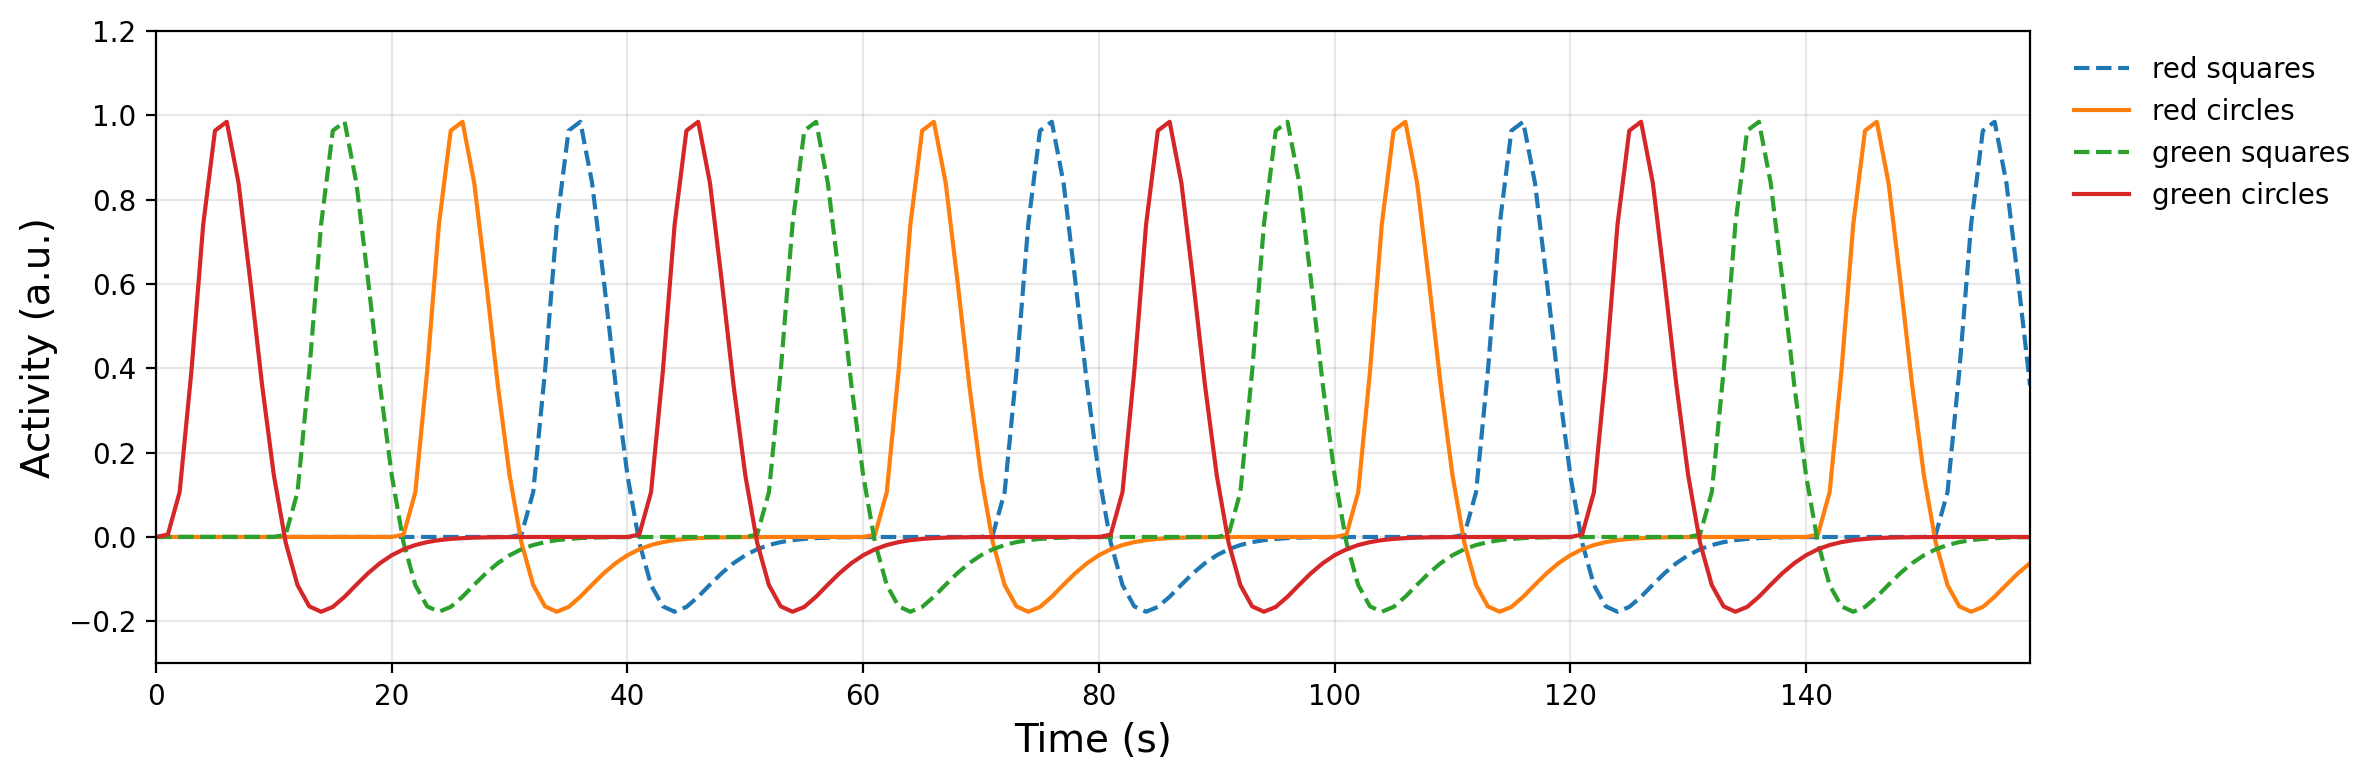

In [6]:
# --- Parameters --------------------------------------------------------------
exp_length = 160  # total duration in seconds
TR = 1            # sampling interval in seconds

# --- Event design ------------------------------------------------------------
# Four conditions: red squares (rq), red circles (rc), green squares (gs), green circles (gc)
onsets = np.array(
    [0, 40, 80, 120,    # red squares
     10, 50, 90, 130,   # red circles
     20, 60, 100, 140,  # green squares
     30, 70, 110, 150]  # green circles
)
conditions = (['rq'] * 4) + (['rc'] * 4) + (['gs'] * 4) + (['gc'] * 4)

# --- Simulate voxel signal + design matrix (revised API) --------------------
y, X_tr, betas_hat, t_tr = simulate_signal(
    onsets=onsets,
    conditions=conditions,
    TR=TR,
    duration=exp_length,
    intercept=0.0,
    beta_canonical=[1, 2, 3, 4],
    beta_time_deriv=None,   # or e.g. [0, 0, 0, 0]
    rng=np.random.default_rng(42),
    plot=False
)

# X_tr columns: [intercept] + [P canonical] + [P time-derivative]
# Keep intercept + the four canonical regressors (first 5 columns).
X_can = X_tr[:, :5]

# --- Plot canonical regressors ----------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(t_tr, X_can[:, 1], linestyle='--', label='red squares')
plt.plot(t_tr, X_can[:, 2], linestyle='-',  label='red circles')
plt.plot(t_tr, X_can[:, 3], linestyle='--', label='green squares')
plt.plot(t_tr, X_can[:, 4], linestyle='-',  label='green circles')

plt.xlim(t_tr[0], t_tr[-1])
plt.ylim(-0.3, 1.2)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Activity (a.u.)', fontsize=14)
plt.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div class='alert alert-warning'>  
<b>ToDo</b> (2 points):  

Time to refresh your GLM skills!  

- Fit a linear regression using the design matrix provided above (<tt>X_can</tt>).  
- Store the estimated regression coefficients (the $\hat{\beta}$’s) in a variable called <tt>betas_todo</tt>.  
- ⚠️ Remember to check whether the design matrix already includes an **intercept** before fitting the model.  

</div>  

In [7]:
from numpy.linalg import inv

# YOUR CODE HERE
betas_todo = inv(X_can.T @ X_can) @ X_can.T @ y
betas_todo
print("Estimated betas:", betas_todo)
# raise NotImplementedError()

Estimated betas: [-0.11517237  1.30389588  2.09869997  2.91421825  4.20446597]


In [8]:
# Feedback cell
if "betas_todo" not in locals():
    print('The variable "betas_todo" is not defined. Check that you created and named the variable correctly.')
elif not betas_todo.shape == (5,):
    print('"betas_todo" should be a vector with shape (5,).')
elif not np.isclose(np.sum(betas_todo), 9.99, rtol=1e-2):
    print('Hmm, something seems off. Please check your answer.')
else:
    print('Well done! Your answer passed the automated checks.')

Hmm, something seems off. Please check your answer.


From the figure above, you can see that many different contrasts are possible!  
One important class of contrasts are **main effects**: the effect of one factor while collapsing over the other(s).  

For example:  
- *Does brain activity differ between red and green stimuli, regardless of shape?*  

Technically, main effects in factorial designs are often evaluated with **F-tests**.  
An F-test is non-directional: it checks for *any* difference between conditions (e.g., red ≠ green, which could mean either red > green or green > red).  

In practice, however, most hypotheses in cognitive neuroscience are **directional** (e.g., red > green).  
Therefore, in this course we’ll focus on setting up **directional contrasts** when working with factorial designs.  

<div class='alert alert-warning'>  
<b>ToDo</b> (1 point):  

Define a contrast vector (a NumPy array with 5 values) named <tt>cvec_red_green</tt>.  
This vector should test the hypothesis:  

**Red stimuli evoke more activity than green stimuli (collapsing across shape).**  

</div>  

In [9]:
# --- Define your contrast vector here ---
# YOUR CODE HERE
cvec_red_green = np.array([0, 1, 1, -1, -1])
print(cvec_red_green)
# raise NotImplementedError()

[ 0  1  1 -1 -1]


In [10]:
# Feedback cell
if "cvec_red_green" not in locals():
    print('The variable "cvec_red_green" is not defined. Check that you created and named the variable correctly.')
elif not cvec_red_green.shape == (5,):
    print('"cvec_red_green" should be a vector with shape (5,).')
elif not np.sum(cvec_red_green) == 0:
    print('Hmm, something seems off. Please check your answer.')
else:
    print('Your answer passed the automatic check.')

Your answer passed the automatic check.


<div class='alert alert-warning'>  
<b>ToDo</b> (1 point):  

Another possible hypothesis is:  

**Circles evoke more activity than squares (collapsing across color).**  

Define a contrast vector (a NumPy array with 5 values) named <tt>cvec_circle_square</tt> that tests this hypothesis.  
</div>  

In [11]:
# --- Define your contrast vector here ---
### BEGIN SOLUTION
cvec_circle_square = np.array([0, -1, 1, -1, 1])
### END SOLUTION

In [12]:
# Feedback cell
if "cvec_circle_square" not in locals():
    print('The variable "cvec_circle_square" is not defined. Check that you created and named the variable correctly.')
elif not cvec_circle_square.shape == (5,):
    print('"cvec_circle_square" should be a vector with shape (5,).')
elif not np.sum(cvec_circle_square) == 0:
    print('Hmm, something seems off. Please check your answer.')
else:
    print('Your answer passed the automated checks.')

Your answer passed the automated checks.


The directional **main effects** we just covered should feel familiar — they work much like the contrasts you saw last week.  

What makes **factorial designs** unique is that they also allow you to test for **interactions** between factors.  
Technically, interactions are often assessed with non-directional *F*-tests, but in cognitive neuroscience it is more common to test **directional hypotheses** with *t*-tests.  

---

### Example: an interaction  

Suppose we hypothesize that:  

- Red stimuli evoke more activity than green stimuli,  
- **and** this effect is stronger for circles than for squares.  

Formally:  

$$
(\hat{\beta}_{\text{red,circle}} - \hat{\beta}_{\text{green,circle}}) 
\;>\; 
(\hat{\beta}_{\text{red,square}} - \hat{\beta}_{\text{green,square}})
$$

---

### A useful trick  

To build a contrast for this kind of interaction, you don’t have to start from scratch.  
Instead, you can simply **multiply the two main-effect contrast vectors elementwise**:  

- contrast for *red > green*  
- contrast for *circle > square*  

Their product gives you the interaction contrast.  

<div class='alert alert-warning'>  
<b>ToDo</b> (1 point):  

Define a contrast vector named <tt>cvec_interaction</tt> that tests the following hypothesis:  

**Red stimuli evoke more activity than green stimuli, with a stronger effect for circles than for squares.**  

(This is the interaction contrast described in the example above.)  
</div>  

In [13]:
# --- Implement your solution here ---
# YOUR CODE HERE
cvec_interaction = np.array([0, -1, 1, 1, -1])
# raise NotImplementedError()

In [14]:
# Feedback cell
if "cvec_interaction" not in locals():
    print('The variable "cvec_interaction" is not defined. Check that you created and named the variable correctly.')
elif not cvec_interaction.shape == (5,):
    print('"cvec_interaction" should be a vector with shape (5,).')
elif not np.sum(cvec_interaction) == 0:
    print('Hmm, something seems off. Please check your answer.')
else:
    print('Your answer passed the automated checks.')

Your answer passed the automated checks.


<div class='alert alert-warning'>  
<b>ToDo</b> (1 point):  

Define a contrast vector named <tt>cvec_interaction2</tt> that tests the hypothesis:  

**Squares evoke more activity than circles, with the difference being smaller for green stimuli than for red stimuli.**  
</div>  

In [15]:
# --- Implement your solution here ---
# YOUR CODE HERE
cvec_interaction2 = np.array([0, 1, -1, -1, 1])
# raise NotImplementedError()

In [16]:
# Feedback cell
if "cvec_interaction2" not in locals():
    print('The variable "cvec_interaction2" is not defined. Check that you created and named the variable correctly.')
elif not cvec_interaction2.shape == (5,):
    print('"cvec_interaction2" should be a vector with shape (5,).')
elif not np.sum(cvec_interaction2) == 0:
    print('Hmm, something seems off. Please check your answer.')
else:
    print('Your answer passed the automated checks.')

Your answer passed the automated checks.


### Parametric designs  

So far, we’ve focused on designs with **categorical conditions**, such as *male vs. female faces* or *circles vs. squares*.  
But the independent variables in an experiment don’t always have to be categorical — they can also be **continuous** or **ordinal**.  
When a predictor varies in value across trials, this is called a **parametric design** (or *parametric modulation*).  

In parametric designs, the voxel response is modeled as:  
1. an **unmodulated response** (the general response to the stimulus/task, independent of the parametric value), and  
2. a **parametric modulation** of that response (scaling with the value of the parameter).  

---

#### Example: reward study  

Imagine an fMRI experiment on reward processing:  

- Each trial begins with the word *“guess”* on screen for 1 second.  
- Participants guess a number between 1 and 10 using an MRI-compatible button box.  
- Beforehand, they are told:  
  - Exact guess → **1 euro reward**  
  - Each number off → **10 cents less** (e.g., correct = 7, guess = 5 → €0.80 reward).  
- After a 4-second interval, participants see the amount they won displayed on the screen.  

![](https://docs.google.com/drawings/d/e/2PACX-1vQE7azl2uFrK7sWOEvb-OgnFefGbFmwpPB6QmYZj8fPNRXaOulZYnXJZWD5FRnqGq_F5nNVw5oUCyLX/pub?w=950&h=397)  

---

One hypothesis here might be:  
*Are there voxels whose activity scales with reward magnitude?*  
For instance, does activity increase for larger rewards (or decrease, in other regions)?  

To explore this, let’s simulate some hypothetical data:  
- Total experiment time = 10 minutes  
- 30 trials with varying reward magnitudes  
- TR = 1 second  
- Onsets of reward presentation aligned to the TR (simplified assumption, so we can ignore up/downsampling issues).  

Number of trials: 30


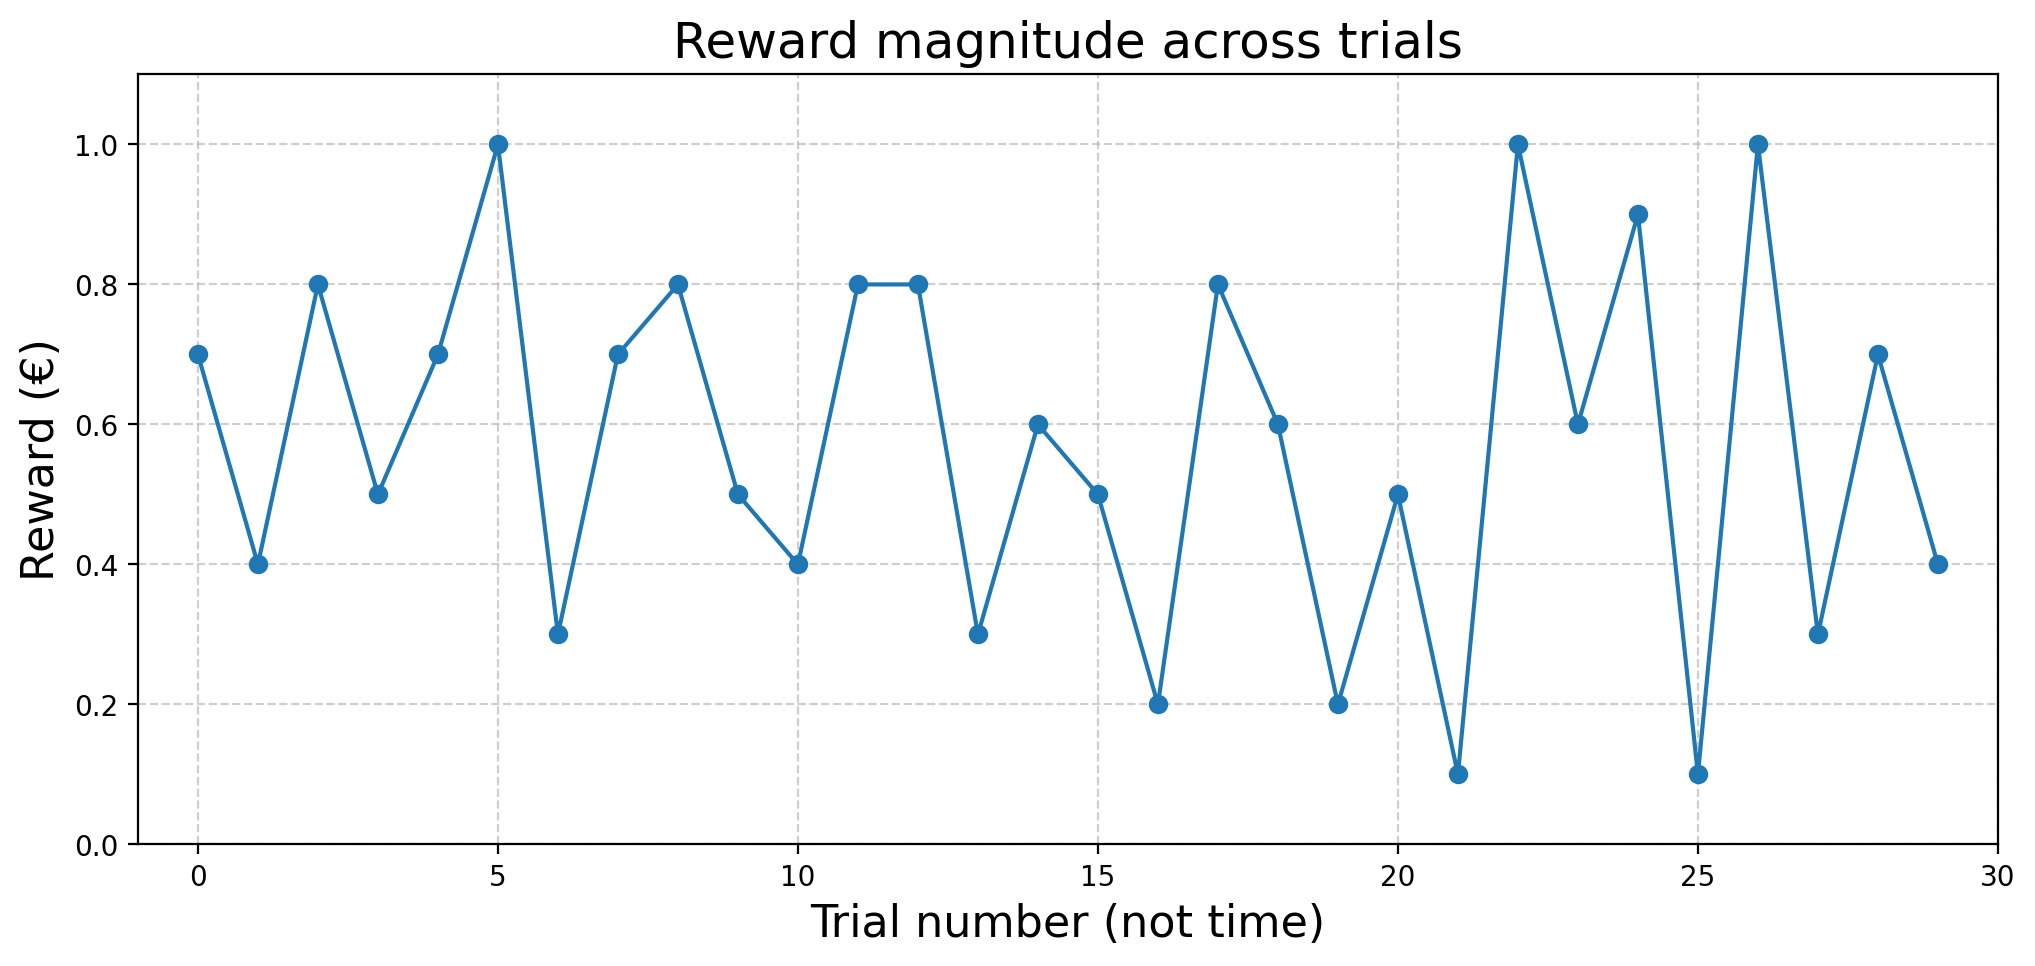

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulate reward experiment setup ---
np.random.seed(42)

exp_time = 60 * 10       # total experiment time in seconds (10 minutes)
n_trials = 30            # number of trials
reward_onsets = np.linspace(4, exp_time, n_trials, dtype=int)  # reward event onsets (simplified)

print(f"Number of trials: {reward_onsets.size}")

# Reward magnitudes: random values between 0.1 and 1.0 euros
reward_magnitudes = np.random.randint(1, 11, size=n_trials) / 10

# --- Plot reward magnitudes per trial ---
plt.figure(figsize=(12, 5))
plt.plot(reward_magnitudes, marker="o", linestyle="-", linewidth=1.5)

plt.xlim(-1, n_trials)
plt.ylim(0, 1.1)
plt.xlabel("Trial number (not time)", fontsize=16)
plt.ylabel("Reward (€)", fontsize=16)
plt.title("Reward magnitude across trials", fontsize=18)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In a **categorical design**, regressors are typically built as **stick functions**: zeros everywhere, with ones at stimulus onsets (or wherever we expect neural activity to influence the fMRI signal).  

In a **parametric design**, we add an extra step. For each parametric modulation, we include:  
1. an **unmodulated regressor** (captures the general response to the event, regardless of the parameter), and  
2. a **modulated regressor** (captures how the response scales with the parameter value).  

Let’s begin with the unmodulated response.  
This predictor is constructed in the usual way: by convolving a stick function with a canonical HRF:  

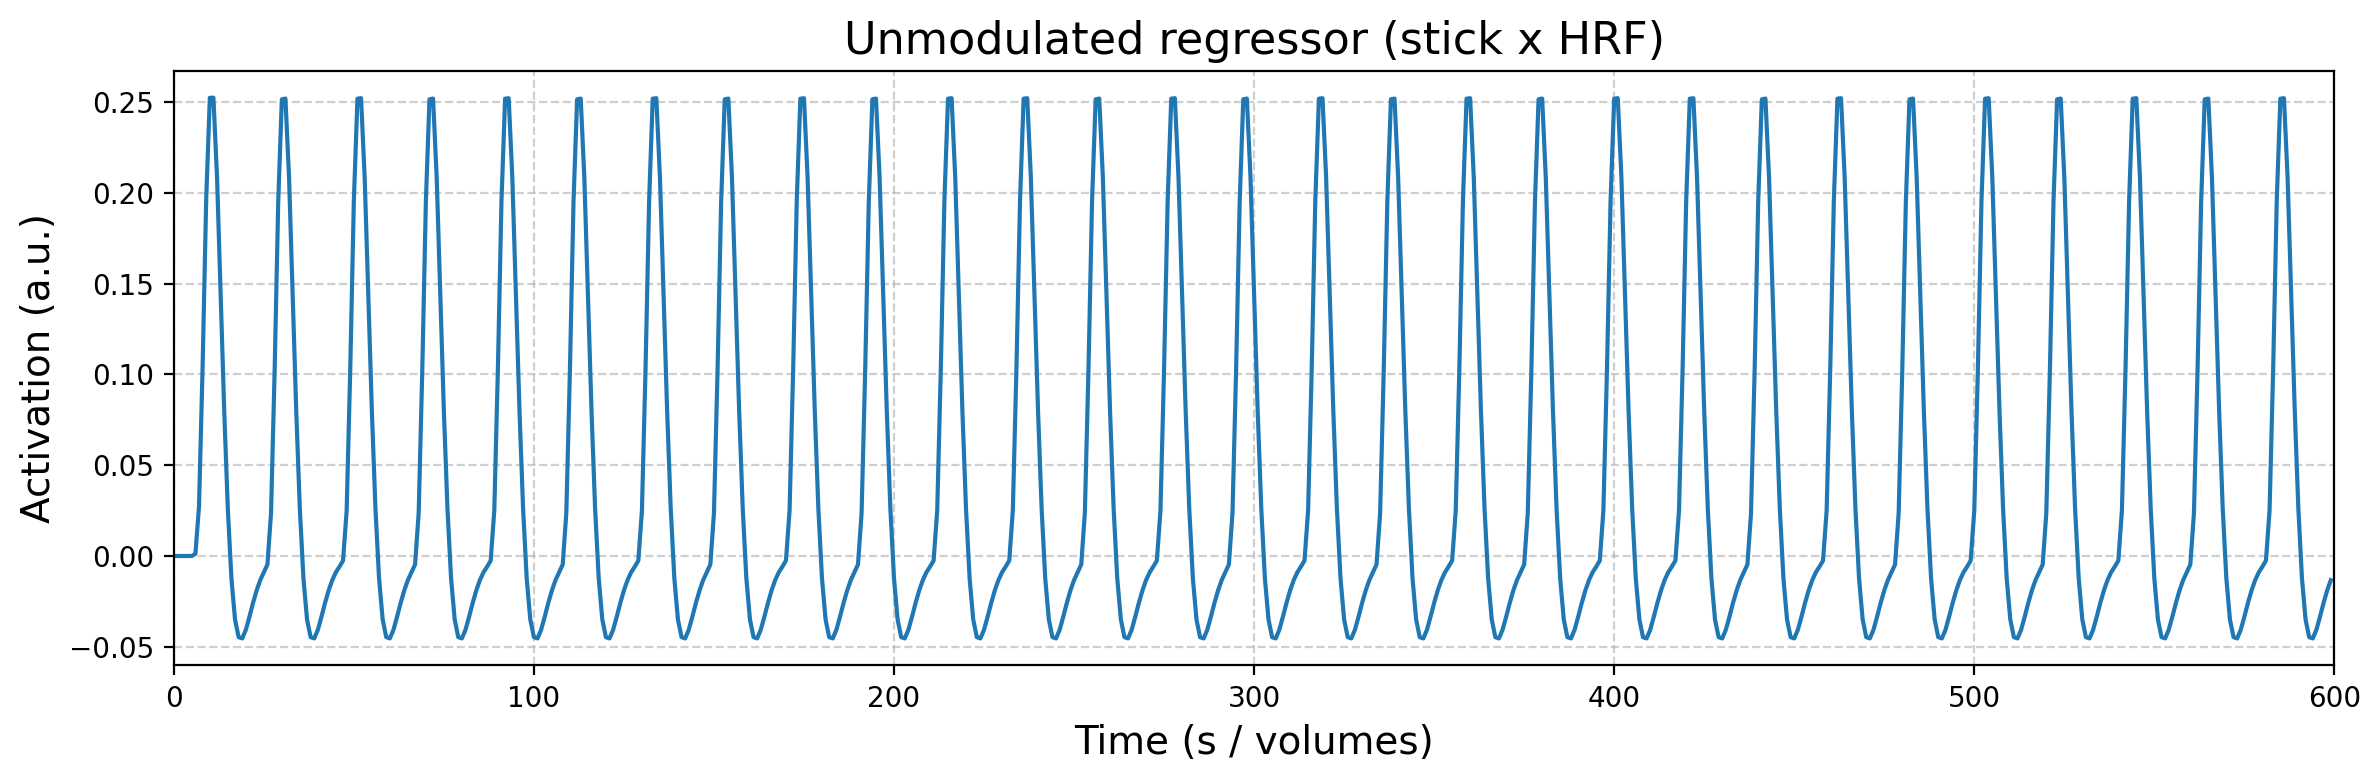

In [18]:
# --- Build the unmodulated regressor (stick function → HRF convolution) ---

TR = 1  # seconds per volume
hrf = glover_hrf(tr=TR, oversampling=1)  # canonical HRF sampled at TR

# Stick function: 1 at reward onsets, 0 elsewhere
x_unmod = np.zeros(exp_time, dtype=float)          # exp_time is total duration in seconds/vols
valid_onsets = np.clip(reward_onsets, 0, exp_time-1)  # guard against any out-of-bounds indices
x_unmod[valid_onsets] = 1.0

# Convolve with HRF and truncate to original length
x_unmod = np.convolve(x_unmod, hrf, mode="full")[:exp_time]

# --- Plot ---
plt.figure(figsize=(12, 4))
plt.plot(x_unmod, linewidth=1.5)
plt.xlim(0, exp_time)
plt.xlabel("Time (s / volumes)", fontsize=14)
plt.ylabel("Activation (a.u.)", fontsize=14)
plt.title("Unmodulated regressor (stick x HRF)", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

The **parametrically modulated regressor** is built in almost the same way as the unmodulated one —  
but instead of inserting *ones* at the reward onsets, we use the **reward magnitudes**.  

Importantly, we first **subtract the mean** from these magnitudes.  
Why? Because this ensures that the modulated regressor is not correlated with the unmodulated regressor.  
In other words, it explains only the variance due to **changes in reward size**, not the general response to the stimulus.  
This step is also known as **orthogonalising** the parametric regressor with respect to the unmodulated regressor.  

Finally, as before, we convolve this regressor with the HRF to obtain the predictor used in the GLM.  

<div class='alert alert-warning'>  
<b>ToDo</b> (1 point):  

Create the **parametrically modulated regressor**:  

1. Subtract the mean from the parametric values (<tt>reward_magnitudes</tt>) and store the result in <tt>reward_magnitudes_ms</tt>.  
   *(Tip: you don’t need a for-loop — use vectorised operations!)*  
2. Create a zeros-filled predictor and insert the mean-subtracted reward magnitudes at the reward onsets.  
3. Convolve this predictor with the HRF (use <tt>hrf</tt> defined earlier).  
4. Trim the convolved predictor back to the original experiment length.  
5. Store the final regressor in <tt>x_mod</tt> and plot it.  

</div>  

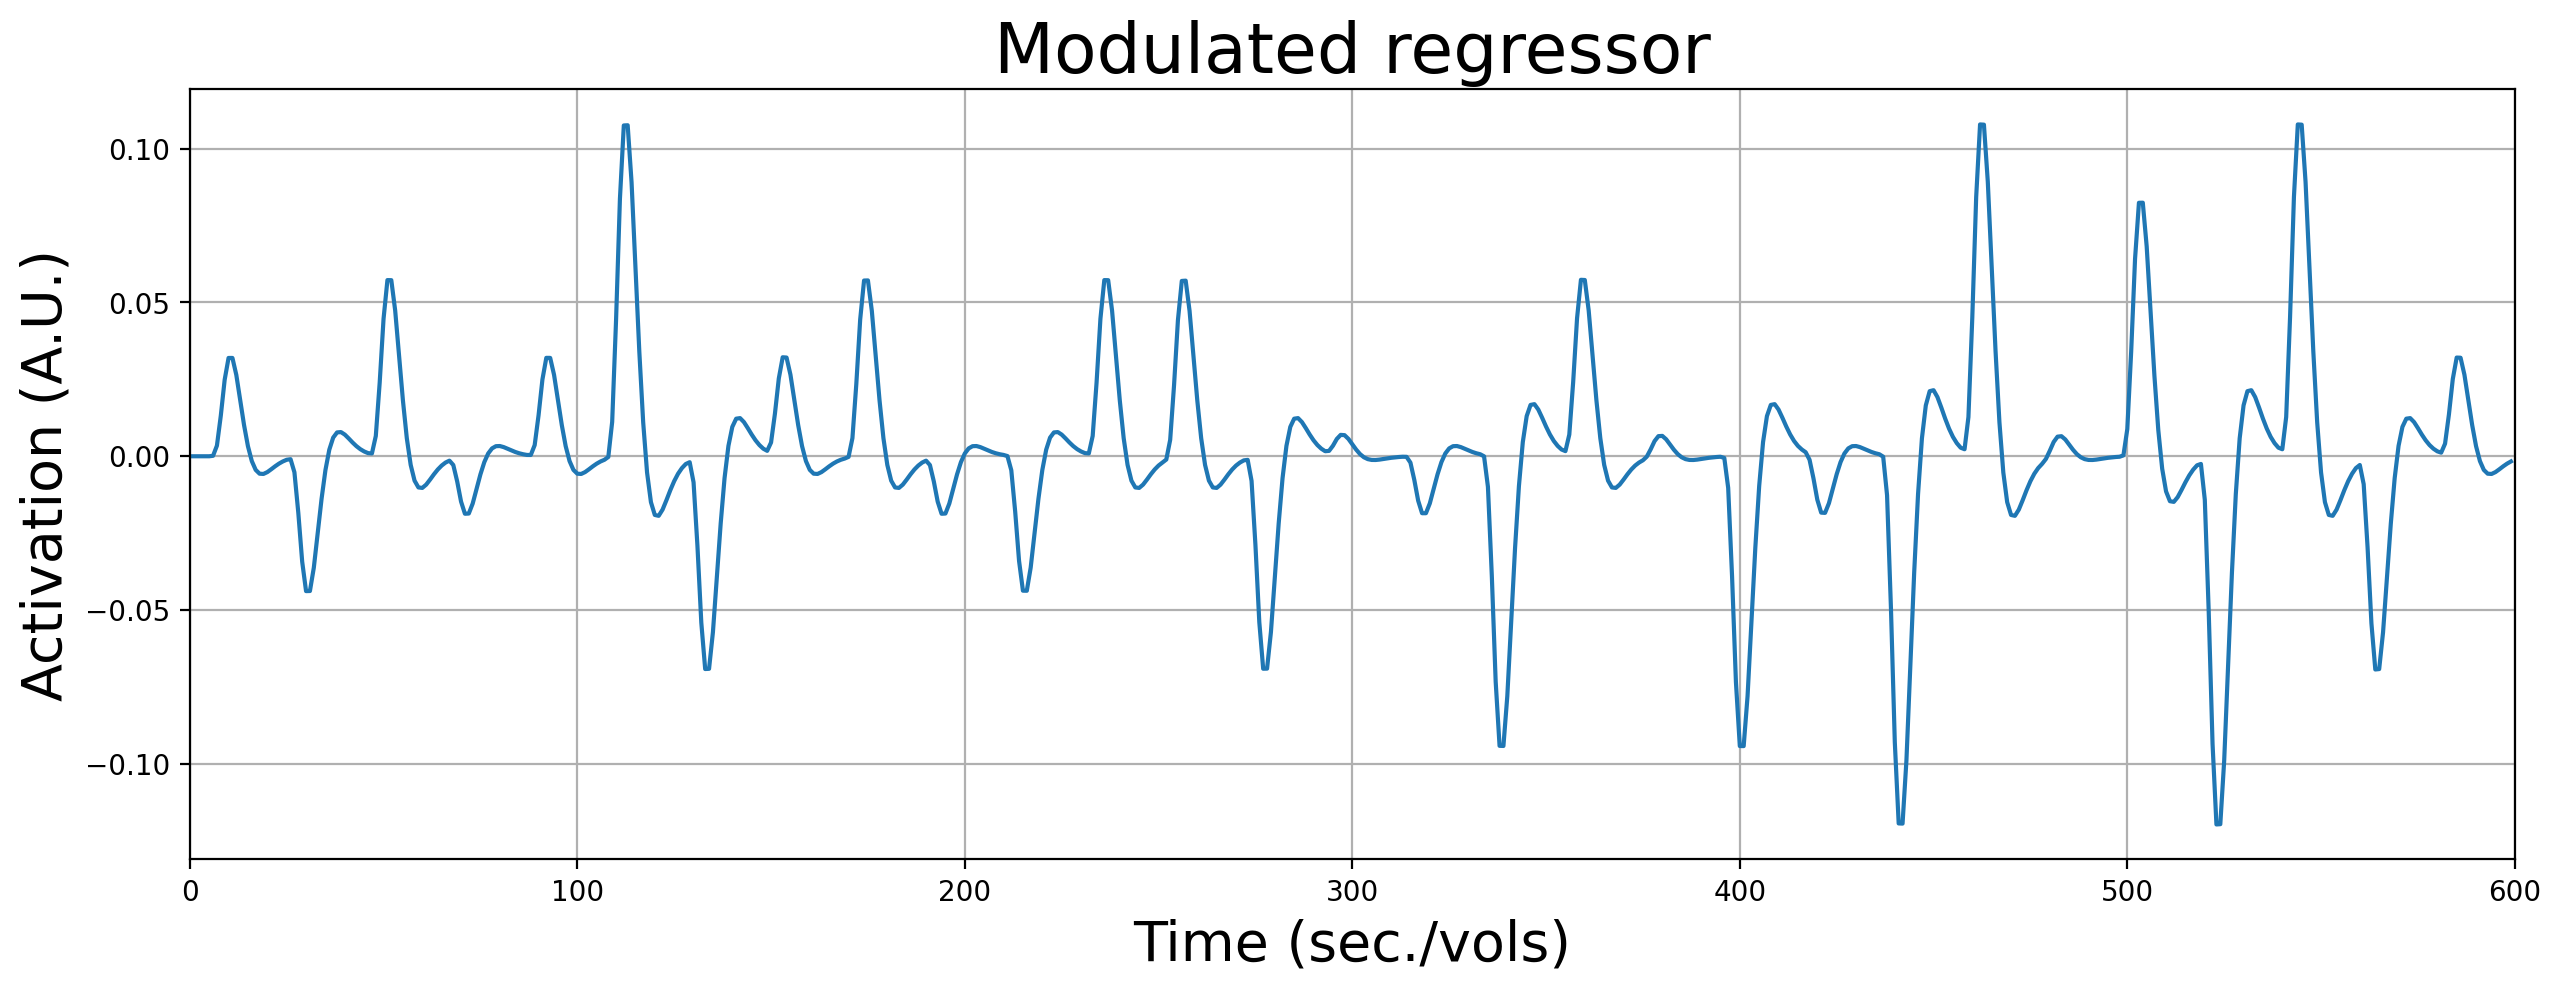

In [19]:
# --- Implement your ToDo here. ---

# YOUR CODE HERE

# subtracting mean from parametric values
import numpy as np

reward_magnitudes_ms = reward_magnitudes - reward_magnitudes.mean()
x_mod = np.zeros(exp_time)

# Filter indices within valid range
valid_idx = reward_onsets < exp_time
x_mod[reward_onsets[valid_idx]] = reward_magnitudes_ms[valid_idx]

x_mod = np.convolve(x_mod, hrf)[:exp_time]
# plotting code follows
plt.figure(figsize=(15, 5))
plt.plot(x_mod)
plt.xlim(0, exp_time)
plt.xlabel('Time (sec./vols)', fontsize=20)
plt.ylabel('Activation (A.U.)', fontsize=20)
plt.title('Modulated regressor', fontsize=25)
plt.grid()
plt.show()
# raise NotImplementedError()

In [20]:
# Feedback cell
if "x_mod" not in locals():
    print('The variable "x_mod" is not defined. Check that you created and named the variable correctly.')
elif not x_mod.shape == (600,):
    print('"x_mod" should be a an array with shape (600,).')
elif not np.isclose(np.sum(x_mod), 0.174, rtol=1e-2):
    print('Hmm, something seems off. Please check your answer.')
else:
    print('Your answer passed the automated checks.')

Hmm, something seems off. Please check your answer.


<div class='alert alert-warning'>
<b>ToDo</b> (1 point):

Build a three-column design matrix and fit the GLM to the reward signal.

1) **Design matrix (X_reward):** stack, in this order  
&nbsp;&nbsp;&nbsp;&nbsp;• column 1: **intercept** (ones)  
&nbsp;&nbsp;&nbsp;&nbsp;• column 2: **unmodulated regressor** (<tt>x_unmod</tt>)  
&nbsp;&nbsp;&nbsp;&nbsp;• column 3: **modulated regressor** (<tt>x_mod</tt>)  
&nbsp;&nbsp;&nbsp;&nbsp;*(Tip: ensure each is a column vector; use <tt>np.newaxis</tt> or <tt>np.column_stack</tt>.)*

2) **Fit linear regression** on <tt>y_reward_signal</tt> using this design matrix.

3) **Store** the estimated parameters in <tt>betas_reward</tt>.

</div>

In [21]:
import numpy as np
# Loading the signal
y_reward_signal = np.load("y_reward_signal.npy")

# --- Implement your ToDo here ---
# YOUR CODE HERE
intercept = np.ones(exp_time, np.int8)

X2 = np.hstack((intercept[:,np.newaxis], x_unmod[:,np.newaxis], x_mod[:,np.newaxis]))

betas_reward = inv(X2.T @ X2) @ X2.T @ y_reward_signal
betas_reward
# raise NotImplementedError()

print("Estimated betas [intercept, unmodulated, modulated]:")
print(betas_reward)

Estimated betas [intercept, unmodulated, modulated]:
[ 0.05654467 -0.11920853  0.34654266]


In [22]:
# Feedback cell
if "betas_reward" not in locals():
    print('The variable "betas_reward" is not defined. Check that you created and named the variable correctly.')
elif not betas_reward.shape == (3,):
    print('"betas_reward" should be a an array with shape (3,).')
elif not np.isclose(np.sum(betas_reward), 0.327, rtol=1e-2):
    print('Hmm, something seems off. Please check your answer.')
else:
    print('Your answer passed the automated checks.')

Hmm, something seems off. Please check your answer.


<div class='alert alert-info'>  
<b>ToThink</b> (1 point):  

Look at the estimated betas for the **unmodulated** and **modulated** predictors.  

👉 What do their signs (positive/negative) tell you about this voxel’s response?  
- How does the voxel respond to reward events in general (unmodulated predictor)?  
- How does the voxel’s response scale with reward magnitude (modulated predictor)?  

Write your interpretation below.  
    
💡 Keep your explanation concise — this will be graded manually (no feedback cell).
</div>  

In general, the voxel responds to stimuli with increased activity \(as seen in the unmodulated predictor\). More specifically, the modulated predictor indicates that the voxel shows increased activity when the reward is higher. 


## Design variance and efficiency  

So far, you’ve learned how to set up contrasts for factorial and parametric designs.  
In this section, we’ll shift gears and focus on the **mathematics of design variance and efficiency**.  

You might remember that in the earlier GLM tutorials we postponed explaining what *design variance* really means.  
Now it’s time to dive into it in detail.  

---

### Recap: the *t*-value  

Last week you learned how to use the GLM to estimate how much influence each predictor has on voxel activity.  
The key insight was that we don’t interpret raw $\hat{\beta}$ values directly, but instead their **normalized version**: the *t*-value.  

For a given contrast $\mathbf{c}$:  

\[
t_{\mathbf{c}\hat{\beta}} = 
\frac{\text{effect}}{\sqrt{\text{noise} \cdot \text{design variance}}}
= \frac{\mathbf{c}\hat{\beta}}{\sqrt{\tfrac{SSE}{DF} \cdot \text{design variance}}}
\]  

This formula highlights that *t*-values — the statistics we truly care about — depend on three components:  
- the **effect** ($\mathbf{c}\hat{\beta}$, sometimes called the *signal*),  
- the **noise** ($\hat{\sigma}^2 = \tfrac{SSE}{DF}$),  
- and the **design variance**.  

---

### Why this matters  

To maximize *t*-values (and thus statistical power), we want to:  
1. **maximize the effect** of predictors (large $\hat{\beta}$),  
2. **minimize noise** ($\hat{\sigma}^2$),  
3. **minimize design variance**.  

In this lab, we’ll briefly revisit the **effect** term, then focus in depth on **design variance**.  
The **noise** component will be the topic of next week’s lab on preprocessing.  

### Optimizing “effects”  

#### Psychological factors  
In the *t*-value formula, the **effect** term refers to the $\beta$-parameter.  
At first, it may seem odd to talk about “optimizing” your effect — after all, you can’t magically boost the brain’s response (short of using a stronger MRI scanner).  

But remember: the effect you measure comes from **human participants**.  
Psychological factors can strongly influence the strength of the signal, and therefore the size of your $\beta$’s.  

Examples include:  
- inattention or boredom,  
- anxiety or stress,  
- sleepiness (yes, people really do fall asleep in the scanner),  
- or simply not understanding the task.  

**Extreme but real example:**  
If you’re testing visual responses to stimulus color, and the participant falls asleep halfway through the run, your estimated $\beta$ will be much smaller than if they had stayed awake and engaged.  

In short: when designing an experiment, continually ask yourself:  
- *Are participants really doing what I want them to do?*  
- *Am I truly measuring the process I think I’m measuring?*  

For a deeper dive, see Tor Wager’s excellent video [*Psychological principles in experimental design*](https://www.youtube.com/watch?v=lwy2k8YQ-cM) (also linked on Canvas).  

---

#### Design factors  
Beyond psychology, certain **technical aspects of design** also influence the potential strength of your signal.  
For example, blocked designs typically yield stronger effects than event-related designs.  

We’ll return to these issues later in the notebook, after introducing another key part of the *t*-value denominator: **design variance**.  

### Optimizing design variance  

Last week we introduced the mysterious term *design variance* and promised to return to it.  
Now it’s time to unpack what it really means.  

---

#### What is design variance?  

Recall from the *t*-value formula that part of the standard error comes from the **design matrix ($X$)**.  
This component is called **design variance**, and it captures how well your design allows you to estimate a given contrast.  

A closely related concept is **efficiency**, which is simply the inverse of design variance:  

$$
\text{efficiency} = \frac{1}{\text{design variance}}
$$

So:  
- **High design variance → low efficiency** (bad, less power).  
- **Low design variance → high efficiency** (good, more power).  

---

#### What makes a design efficient?  

Two key properties contribute to efficiency:  

1. **High variance of predictors**  
   - Predictors should vary strongly relative to their mean.  
   - More variability = more information to estimate effects.  

2. **Low covariance between predictors**  
   - Predictors should not overlap too much.  
   - If predictors are highly correlated, it’s difficult to tease apart their individual effects.  

---

#### Mathematical definitions  

For a contrast between two predictors $j$ and $k$, design variance can be expressed as:  

$$
\text{design variance}_{j,k} = \frac{1}{\text{var}[X_j] + \text{var}[X_k] - 2 \cdot \text{cov}[X_j, X_k]}
$$

and efficiency is the inverse:  

$$
\text{efficiency}_{j,k} = \text{var}[X_j] + \text{var}[X_k] - 2 \cdot \text{cov}[X_j, X_k]
$$ 

For a **contrast against baseline** (just one predictor), the formula simplifies to:  

$$
\text{design variance}_{j} = \frac{1}{\text{var}[X_j]}
$$

---

#### General definition  

Since it’s cumbersome to switch formulas depending on the type of contrast,  
we usually rely on a **vectorized definition** that works for *any* contrast vector $\mathbf{c}$:  

$$
\text{design variance} = \mathbf{c}(X^TX)^{-1}\mathbf{c}^T
$$

Here:  
- $(X^TX)^{-1}$ is the variance–covariance matrix of the design,  
- $\mathbf{c}$ is the contrast vector, which “selects” the relevant variances and covariances for the contrast.  

This looks more abstract, but it’s mathematically equivalent to the variance/covariance formulas above.  
The big advantage: it works for both simple contrasts (e.g. `[0, 0, 1]`) and more complex ones (e.g. `[0, 1, -1]`).  

---

#### Connecting back to the *t*-statistic  

Plugging this definition of design variance into the standard error, we get:  

$$
SE_{\mathbf{c}\hat{\beta}} = \sqrt{\hat{\sigma}^{2}\mathbf{c}(X^TX)^{-1}\mathbf{c}^T}
$$  

And therefore, the full *t*-statistic can be written as:  

$$
t_{\mathbf{c}\hat{\beta}} = \frac{\mathbf{c}\hat{\beta}}{\sqrt{\hat{\sigma}^{2}\mathbf{c}(X^TX)^{-1}\mathbf{c}^T}}
= \frac{\text{effect}}{\sqrt{\text{noise} \cdot \text{design variance}}}
$$  

---

\* *Technical note:* strictly speaking, design variance depends on the **sums of squares** of predictors ($SS_{X_j}$) and their **cross-products** ($SS_{X_j, X_k}$), rather than variances and covariances.  
We used the variance/covariance terms here because they are more intuitive. 

### Summary: effects, noise, and design variance  

That was a lot of math — but here’s the big picture.  
To obtain large *t*-values, you need three things:  

1. **Strong effects** (large $\beta$)  
2. **Efficient design** → low design variance  
   - high predictor variance, low predictor covariance  
   - formally: $\mathbf{c}(X^TX)^{-1}\mathbf{c}^T$  
3. **Low noise** (small unexplained variance, $\tfrac{SSE}{DF}$)  

---

In this week’s lab, we focus on (2): **how to optimize design efficiency**.  
Next week, we’ll turn to (3): **how to minimize noise**.  

If you keep these three components in mind — effect, design variance, and noise — you already grasp the most important principle of fMRI experimental design.  

In the rest of this tutorial, we’ll explore **why** high variance and low covariance make your design more efficient,  
and **how** you can achieve this through smart experimental choices.  

<div class='alert alert-warning'>  
<b>ToDo</b> (0 points)  

In the previous section, we introduced several related concepts:  
- **signal** ($\hat{\beta}$),  
- **noise** ($SSE/DF$),  
- **design variance**,  
- **efficiency** (the inverse of design variance).  

Together, these determine the strength of our effects (high *t*-values).  

To make this more concrete, we’ve written a helper function <tt>conceptual_tvalue_calculator</tt>.  
It takes three inputs — signal, noise, and design variance — and returns:  

- the resulting *t*-value, and  
- the design efficiency.  

👉 Your task:  
Experiment by changing the input parameters (<tt>SIGNAL</tt>, <tt>NOISE</tt>, <tt>DESIGN_VARIANCE</tt>) and observe how the outputs change.  
This is not graded — it’s just to help you build intuition.  
</div>  

In [23]:
def conceptual_tvalue_calculator(signal, noise, design_variance):
    """
    Calculate the conceptual t-value and design efficiency from 
    the signal, noise, and design variance components.

    Parameters
    ----------
    signal : float
        The estimated effect (e.g., beta or contrast value).
    noise : float
        The noise estimate (e.g., SSE / DF).
    design_variance : float
        The design variance for the contrast of interest.

    Returns
    -------
    t_value : float
        The conceptual t-value, computed as:
        signal / sqrt(noise * design_variance)
    efficiency : float
        The design efficiency, defined as the inverse of design variance.
    """
    efficiency = 1.0 / design_variance
    t_value = signal / np.sqrt(noise * design_variance)
    return t_value, efficiency

In [24]:
# Change the capitalized variables to see what effect it has on the t-value and efficiency
SIGNAL = 0.5
NOISE = 2.8
DESIGN_VARIANCE = 0.02

effect, efficiency = conceptual_tvalue_calculator(signal=SIGNAL, noise=NOISE, design_variance=DESIGN_VARIANCE)

print("Effect ('t-value'): %.3f" % effect)
print("Efficiency: %.3f" % efficiency)

Effect ('t-value'): 2.113
Efficiency: 50.000


<div class='alert alert-info'>  
<b>ToThink</b> (1 point):  

Why can researchers calculate the **efficiency of a design ($\mathbf{X}$)** without collecting any fMRI data ($\mathbf{y}$)?  

👉 Hint: think about which parts of the *t*-value formula depend only on the design matrix.  
    
💡 Keep your explanation concise — this will be graded manually (no feedback cell).
</div>  

Researchers can calculate the efficiency of a design even before collecting any fMRI data because the design of the experiment depends on the design matrix and the desired contrasts, both of which are known before data is collected. Thus, maximising the efficiency of the design is possible a priori. 


### How to calculate design variance and efficiency in Python  

As discussed above, the formula for **design variance** can be expressed using linear algebra:  

$$
\text{design variance} = \mathbf{c}(X^TX)^{-1}\mathbf{c}^T
$$

You’ve already seen the term $(X^TX)$ when we derived the least squares solution.  
To compute design variance, we simply *pre- and post-multiply* $(X^TX)^{-1}$ by the contrast vector $\mathbf{c}$ and its transpose:  

```python
design_var = c @ inv(X.T @ X) @ c.T
```

Since **efficiency** is defined as the inverse of design variance:

$$
\text{efficiency} = \frac{1}{\mathbf{c}(X^TX)^{-1}\mathbf{c}^T}
$$

we can calculate it in Python with:

```python
efficiency = 1.0 / (c @ inv(X.T @ X) @ c.T)
```

You’ll implement this yourself in a later ToDo.
But first, let’s dig deeper into why high variance and low covariance in the design matrix are so crucial for maximizing t-values.

## The effect of predictor variance on design variance and efficiency  

As discussed earlier, **design variance** depends on two factors:  
1. the **variance** of each predictor, and  
2. the **covariance** between predictors.  

In this section, we’ll focus on predictor **variance**.  
The next section will address predictor covariance.  

---

### Recap: variance  

Variance describes how much a variable’s values spread out around the mean.  
Formally, for a variable $x$ with mean $\bar{x}$ and $N$ observations, the sample variance is:  

$$
\text{var}[x] = \frac{1}{N - 1}\sum_{i=1}^{N}(x_i - \bar{x})^2
$$

So: the more a variable’s values deviate from the mean, the higher its variance.  

---

### Why predictor variance matters  

To demonstrate the effect of predictor variance on design variance (and thus efficiency), we’ll simplify things:  
- no time-series data,  
- just a single condition → one predictor (plus intercept).  

This allows us to isolate why **high variance in predictors** is critical for achieving low standard errors and high *t*-values.  

---

### Example: IQ and income  

Suppose we want to test whether IQ predicts income.  
Here:  
- predictor $\textcolor{orange}{\mathbf{X}} =$ IQ,  
- outcome $\textcolor{blue}{\mathbf{y}} =$ income.  

We collect some data, run a linear regression, and calculate the $\hat{\beta}$, the MSE, and the *t*-value (for the IQ predictor “against baseline”).  

This simple regression example illustrates the same principle that applies in fMRI: predictors with **more variance** lead to **more efficient designs**.  

In [25]:
def calculate_stats_for_iq_income_dataset(iq_income_data, which="lowvar"):
    """
    Calculate regression statistics (beta, MSE, t-value) for the IQ–income dataset.
    
    Parameters
    ----------
    iq_income_data : dict
        Dictionary containing design matrices and outcome vectors.
        Keys: 'X_lv', 'y_lv' for low-variance case,
              'X_hv', 'y_hv' for high-variance case.
    which : str, optional
        Selects which dataset to use: 'lowvar' or 'highvar'.
    
    Returns
    -------
    beta : ndarray
        Estimated regression coefficients.
    mse : float
        Mean squared error of the model.
    tval : float
        t-value for the predictor of interest (IQ against baseline).
    """
    
    # --- Select dataset ---
    if which == "lowvar":
        X, y = iq_income_data["X_lv"], iq_income_data["y_lv"]
    else:
        X, y = iq_income_data["X_hv"], iq_income_data["y_hv"]
    
    # Contrast for IQ predictor (ignores intercept)
    contrast = np.array([0, 1])
    
    # --- Fit OLS regression ---
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    
    # --- Model error ---
    mse = np.mean((y - y_hat) ** 2)  # mean squared error
    sse_df = np.sum((y - y_hat) ** 2) / (X.shape[0] - X.shape[1])  # sigma^2 estimate
    
    # --- Design variance ---
    design_var = contrast @ np.linalg.pinv(X.T @ X) @ contrast.T
    
    # --- Standard error and t-value ---
    se = np.sqrt(sse_df * design_var)
    tval = (contrast @ beta) / se
    
    return beta, mse, tval

Design matrix shape (X_lowvar): (100, 2)
Outcome shape (y_lowvar): (100,)


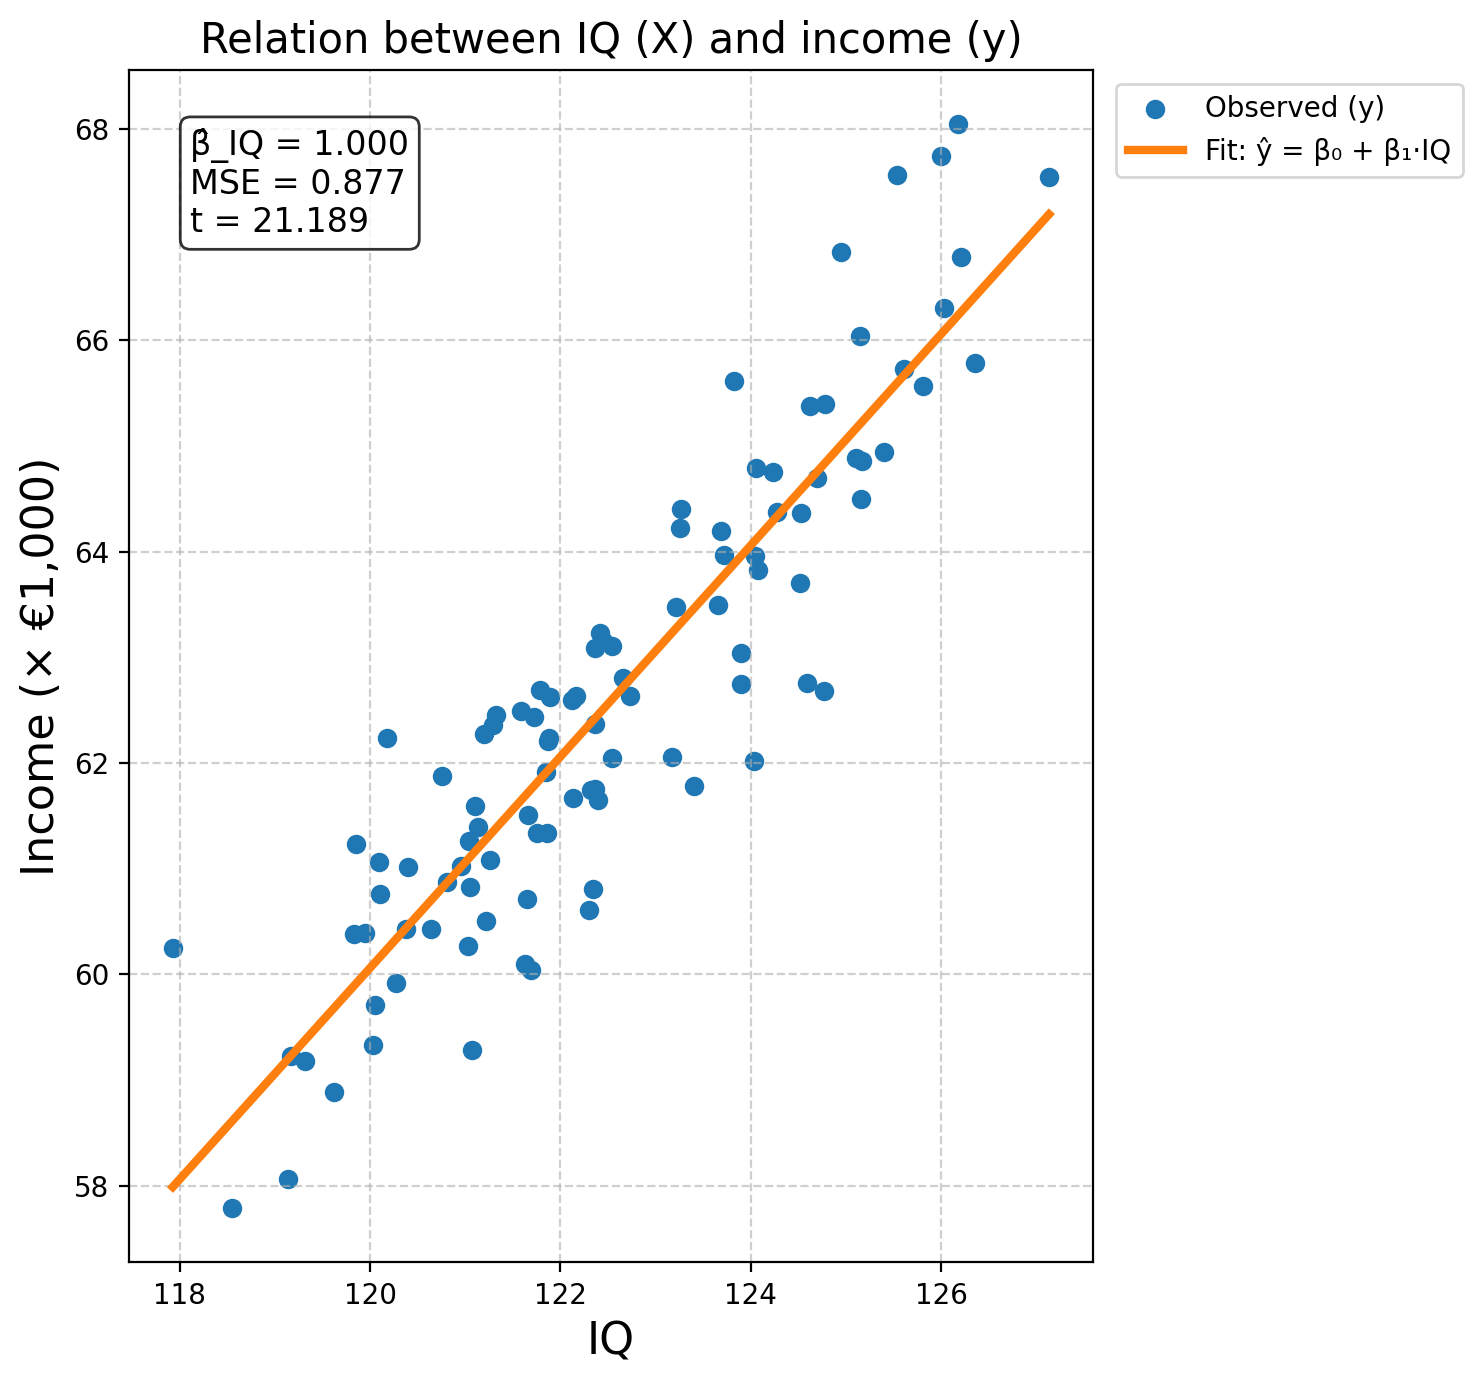

In [26]:
# --- Load data ---
iq_income_data = np.load("iq_variance_example.npz")
X_lowvar = iq_income_data["X_lv"]
y_lowvar = iq_income_data["y_lv"].squeeze()

print(f"Design matrix shape (X_lowvar): {X_lowvar.shape}")
print(f"Outcome shape (y_lowvar): {y_lowvar.shape}")

# --- Fit model & stats for the low-variance case ---
beta_lv, mse_lv, tval_lv = calculate_stats_for_iq_income_dataset(iq_income_data, which="lowvar")

# --- Prepare regression line using data range (no magic numbers) ---
iq_values = X_lowvar[:, 1]                     # predictor column (intercept is column 0)
x_min, x_max = float(iq_values.min()), float(iq_values.max())
x_line = np.array([x_min, x_max])
y_line = beta_lv[0] + beta_lv[1] * x_line

# --- Plot ---
plt.figure(figsize=(7.5, 7))
plt.title("Relation between IQ (X) and income (y)", fontsize=15)

# scatter: y in blue; x-axis is IQ
plt.scatter(iq_values, y_lowvar, color="tab:blue", label="Observed (y)")

# regression line: X in orange
plt.plot(x_line, y_line, color="tab:orange", linewidth=3, label="Fit: ŷ = β₀ + β₁·IQ")

plt.xlabel("IQ", fontsize=16)
plt.ylabel("Income (× €1,000)", fontsize=16)

# Annotate with β, MSE, and t
plt.text(x_min + 0.02*(x_max - x_min), y_lowvar.min() + 0.9*(y_lowvar.max() - y_lowvar.min()),
         f"β̂_IQ = {beta_lv[1]:.3f}\nMSE = {mse_lv:.3f}\nt = {tval_lv:.3f}",
         fontsize=12, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

This dataset looks pretty good!  
On average, our predictions are **less than 1 point off** ($\mathrm{MSE} < 1$).  

But notice something important: the **range of IQ values** ($\textcolor{orange}{X}$) is very limited — we only measured people with IQs between about 118 and 127.  
That’s a very narrow slice, given that IQ in the population is roughly normally distributed with mean 100 and standard deviation 15.  

In other words, we have a decent model, but it’s based on a **restricted range** of the predictor.  
The model captures the IQ–income relationship for relatively high-IQ individuals, but extrapolating to values like 80 or 90 would be very uncertain — because we never measured anyone in that range.  

---

For comparison, let’s look at another dataset where IQ covers a **much wider range**.  
We’ll plot both datasets (low-variance vs. high-variance) side by side.  

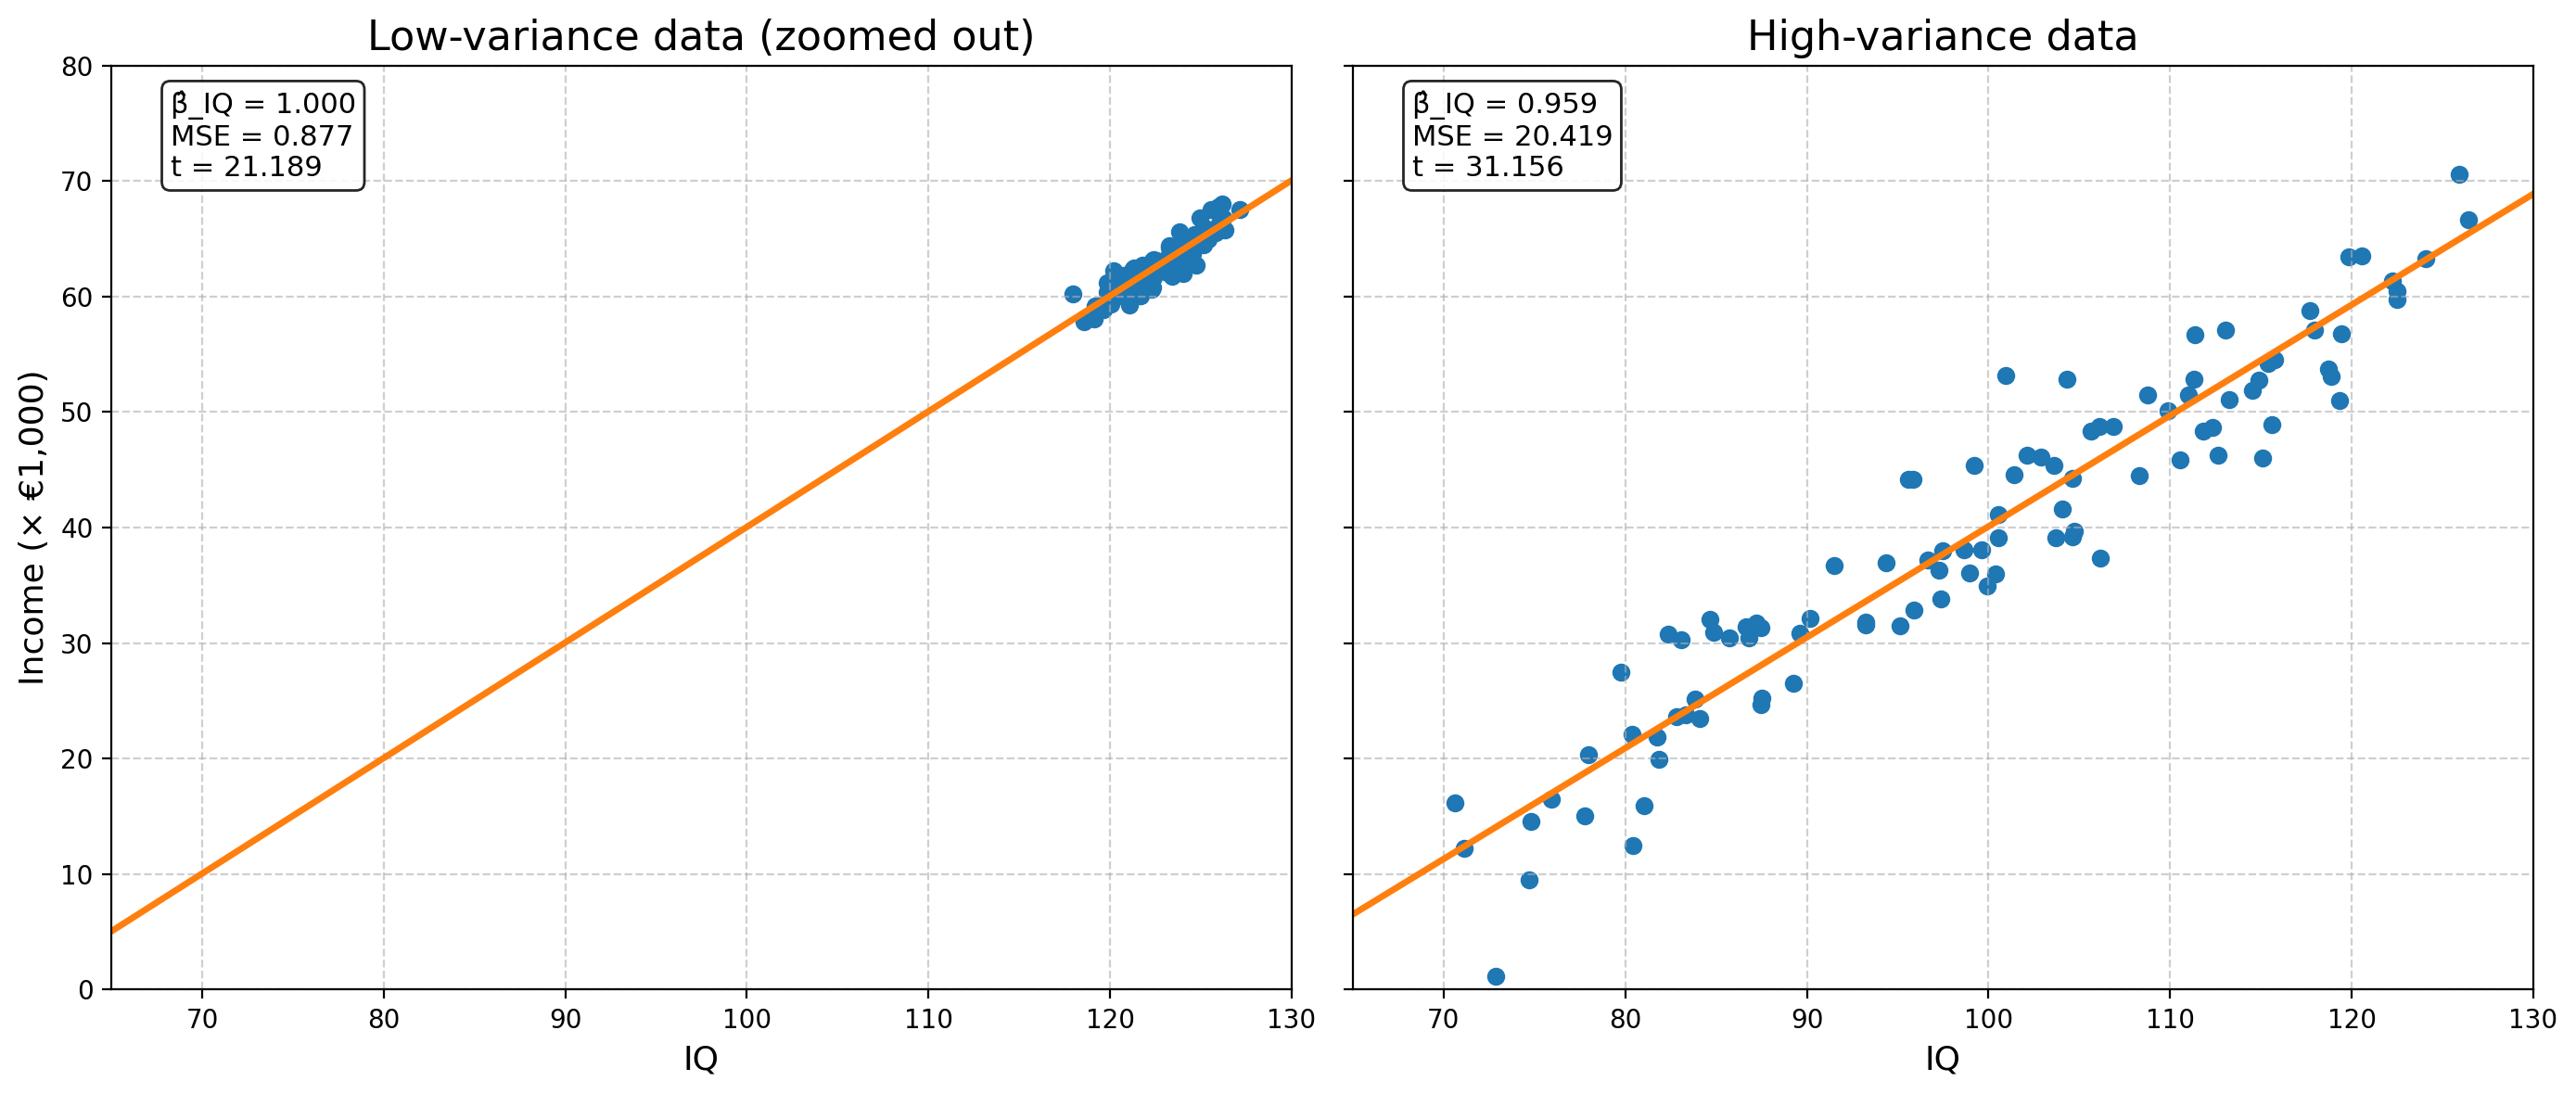

In [27]:
# --- Prepare high-variance dataset ---
X_highvar = iq_income_data["X_hv"]
y_highvar = iq_income_data["y_hv"].squeeze()

# Plot limits (same for both panels)
x_lim = (65, 130)
y_lim = (0, 80)

# Fit model & stats for the high-variance case
beta_hv, mse_hv, tval_hv = calculate_stats_for_iq_income_dataset(iq_income_data, which="highvar")

# Helper: regression line endpoints for a given beta
def reg_line(beta, x_range):
    x0, x1 = x_range
    return (x0, x1), (beta[0] + beta[1] * x0, beta[0] + beta[1] * x1)

# --- Plot side-by-side ---
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Left: low-variance (zoomed out)
axs[0].set_title("Low-variance data (zoomed out)", fontsize=16)
axs[0].scatter(X_lowvar[:, 1], y_lowvar, color="tab:blue", label="Observed (y)")
x_line, y_line = reg_line(beta_lv, x_lim)
axs[0].plot(x_line, y_line, color="tab:orange", linewidth=2.5, label="Fit")
axs[0].set_xlim(*x_lim)
axs[0].set_ylim(*y_lim)
axs[0].set_xlabel("IQ", fontsize=13)
axs[0].set_ylabel("Income (× €1,000)", fontsize=13)
axs[0].grid(True, linestyle="--", alpha=0.6)
axs[0].text(
    x_lim[0] + 0.05 * (x_lim[1] - x_lim[0]),
    y_lim[0] + 0.88 * (y_lim[1] - y_lim[0]),
    f"β̂_IQ = {beta_lv[1]:.3f}\nMSE = {mse_lv:.3f}\nt = {tval_lv:.3f}",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
)

# Right: high-variance
axs[1].set_title("High-variance data", fontsize=16)
axs[1].scatter(X_highvar[:, 1], y_highvar, color="tab:blue", label="Observed (y)")
x_line_hv, y_line_hv = reg_line(beta_hv, x_lim)
axs[1].plot(x_line_hv, y_line_hv, color="tab:orange", linewidth=2.5, label="Fit")
axs[1].set_xlim(*x_lim)
axs[1].set_ylim(*y_lim)
axs[1].set_xlabel("IQ", fontsize=13)
axs[1].grid(True, linestyle="--", alpha=0.6)
axs[1].text(
    x_lim[0] + 0.05 * (x_lim[1] - x_lim[0]),
    y_lim[0] + 0.88 * (y_lim[1] - y_lim[0]),
    f"β̂_IQ = {beta_hv[1]:.3f}\nMSE = {mse_hv:.3f}\nt = {tval_hv:.3f}",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
)

plt.tight_layout()
plt.show()

As you can see in the side-by-side plots, both the **low-variance** dataset (left) and the **high-variance** dataset (right) capture roughly the same relationship:  
for each additional IQ point, income increases by about **€1000** in the low-variance model and about **€959** in the high-variance model.  
These slopes are directly reflected in the $\hat{\beta}$ coefficients.  

However, notice the big difference in model fit: the **MSE is much larger** in the high-variance case.  
This is also visible in the plots — the residuals (the vertical distances of the blue points from the orange regression line) are clearly larger.  

In [28]:
mse_ratio = mse_hv / mse_lv
print("The MSE of the high-variance data is %.3f times larger than the low-variance data!" % mse_ratio)

The MSE of the high-variance data is 23.279 times larger than the low-variance data!


Looking at these statistics, you might expect that the *t*-value for the IQ predictor in the **high-variance** model would be much lower than in the **low-variance** model.  

Let’s put that intuition to the test:  

In [29]:
# We already computed the t-values with calculate_stats_for_iq_income_dataset
print(f"t-value (low-variance model):  {tval_lv:.3f}")
print(f"t-value (high-variance model): {tval_hv:.3f}")

t-value (low-variance model):  21.189
t-value (high-variance model): 31.156


By now you can probably guess the culprit: **design variance**.  
Since the effect size ($\hat{\beta}_{IQ}$) is almost the same in both models, and the MSE is actually *higher* in the high-variance model, the only explanation for the higher *t*-value is that the **design variance in the high-variance model is much lower**.  

<div class='alert alert-warning'>  
<b>ToDo</b> (2 points):  

Use the two design matrices (<tt>X_lowvar</tt> and <tt>X_highvar</tt>) to compute the **design variance** for the IQ predictor in each dataset.  

- This is a *contrast against baseline*:  
$$
H_0: \beta_{IQ} = 0 \quad \text{vs.} \quad H_a: \beta_{IQ} \neq 0
$$
- Therefore, you’ll need a contrast vector that selects the IQ predictor (ignoring the intercept).  

Once you have both design variances, calculate their ratio:  

$$
\texttt{desvar\_ratio} =
\frac{\text{design variance (low-variance)}}{\text{design variance (high-variance)}}
$$

Store the result in a variable named <tt>desvar_ratio</tt>.  
This tells you **how much larger** the design variance is in the low-variance dataset compared to the high-variance dataset.  
</div>  

In [30]:
# --- Implement your ToDo here ---

# YOUR CODE HERE
contrast = np.array([0, 1])
design_var_high = contrast @ inv(X_highvar.T @ X_highvar) @ contrast.T
design_var_low = contrast @ inv(X_lowvar.T @ X_lowvar) @ contrast.T
desvar_ratio = design_var_low / design_var_high
desvar_ratio
# raise NotImplementedError()
print(f"Ratio (low / high): {desvar_ratio:.2f}")

Ratio (low / high): 54.71


In [31]:
# Feedback cell
if "desvar_ratio" not in locals():
    print('The variable "desvar_ratio" is not defined. Check that you created and named the variable correctly.')
elif not np.isscalar(desvar_ratio):
    print('"desvar_ratio" should be a single value.')
elif np.isnan(desvar_ratio) or np.isinf(desvar_ratio):
    print('Your ratio is NaN or infinite. Check your calculation - did you divide by zero?')
elif desvar_ratio <= 0:
    print('Design variance ratios should be positive. Check your calculation.')
else:
    print('Your result looks reasonable.')

Your result looks reasonable.


<div class='alert alert-warning'>  
<b>ToDo</b> (1 point):  

Design efficiency (and design variance) has **no natural unit of measurement**.  
This means that efficiency values are only meaningful **in relative terms** (e.g., comparing one design to another).  

To illustrate this, let’s revisit the **weight–height example** from last week:  
- originally, we used *weight in kilos* as the predictor,  
- now, we’ll rescale weight to be expressed in *grams* instead.  

👉 Your task:  
- Calculate the design efficiency for the weight-in-kilos dataset (<tt>X_kilos</tt>)  
- Calculate the design efficiency for the weight-in-grams dataset (<tt>X_grams</tt>)  
- Store the results in variables named <tt>efficiency_kilos</tt> and <tt>efficiency_grams</tt>  

This will show how rescaling a predictor changes the absolute values of efficiency, but not its relative meaning.  
</div>  

In [32]:
with np.load("weight_height_data.npz") as data:
    X_kilos = data["X"]
    X_grams = X_kilos * 1000  # rescale predictor from kilos → grams
    
    # Add intercept column
    intercept = np.ones((X_kilos.shape[0], 1))
    X_kilos = np.hstack((intercept, X_kilos))
    X_grams = np.hstack((intercept, X_grams))

# --- Implement your ToDo here ---

# YOUR CODE HERE
contrast = np.array([0, 1]) # I assume this ToDo was meant to have a contrast against baseline
efficiency_kilos = 1 / (contrast @ inv(X_kilos.T @ X_kilos) @ contrast.T)
efficiency_grams = 1 / (contrast @ inv(X_grams.T @ X_grams) @ contrast.T)
# raise NotImplementedError()

print(f"Efficiency (weight in kilos): {efficiency_kilos:.6f}")
print(f"Efficiency (weight in grams): {efficiency_grams:.6f}")

Efficiency (weight in kilos): 2997.212652
Efficiency (weight in grams): 2997212652.271739


In [33]:
# Feedback cell
if "efficiency_kilos" not in locals():
    print('The variable "efficiency_kilos" is not defined. Check that you created and named the variable correctly.')
elif not np.isscalar(efficiency_kilos):
    print('"efficiency_kilos" should be a single value.')
elif np.isnan(efficiency_kilos) or np.isinf(efficiency_kilos):
    print('Your efficiency is NaN or infinite. Check your calculation - did you divide by zero?')
elif efficiency_kilos <= 0:
    print('Efficiency should be positive (it\'s the inverse of design variance). Check your calculation.')
else:
    print('Your result looks reasonable.')

Your result looks reasonable.


<div class='alert alert-info'>  
<b>ToThink</b> (1 point):  

If you completed the ToDo above, you should have found that — all else being equal —  
the design using **weight in grams** appears to be **1,000,000 times more efficient** than the design using **weight in kilos**.  

But wait: the rescaling factor was only 1,000.  
So why does the efficiency increase by a factor of a *million* instead of just a thousand? 🤔  

👉 Hint: think about how rescaling a predictor affects the squared terms in the $(X^TX)$ matrix.  
    
💡 Keep your explanation concise — this will be graded manually (no feedback cell).
</div>  

The efficiency is a million times higher because efficiency is based on the sum of the squared deviations from the mean. That is, when the average deviation from the mean is rescaled by a factor of 1000, the efficiency increases by a factor of 1000^2 = 1,000,000. 


## The effect of predictor covariance on design variance and efficiency  

### Multicollinearity  

In the previous section, we saw how **predictor variance** ($\mathrm{var}[\mathbf{X}_j]$) affects the design-variance term:  
high variance → lower design variance → higher efficiency.  

But design variance also depends on the **covariance between predictors** ($\mathrm{cov}[\mathbf{X}_j, \mathbf{X}_k]$).  
This predictor covariance is more commonly known as **multicollinearity**.  

- **High covariance (strong collinearity) → low efficiency**  
- Why? Because correlated predictors introduce **uncertainty** in parameter estimation.  
  If two predictors overlap strongly, the GLM “doesn’t know” how to attribute variance in $\textcolor{blue}{y}$:  
  should it go to predictor A or predictor B?  
  This uncertainty inflates design variance, making estimates less reliable.  

---

### A simulation example  

To see this in action, let’s simulate some fMRI-style time series data:  
- a design with **two predictors**,  
- compute their correlation (as a measure of multicollinearity),  
- calculate the efficiency of the design for the **difference contrast**:  

$$
c = [0, 1, -1]
$$

This will let us compare how predictor covariance directly affects design efficiency.  

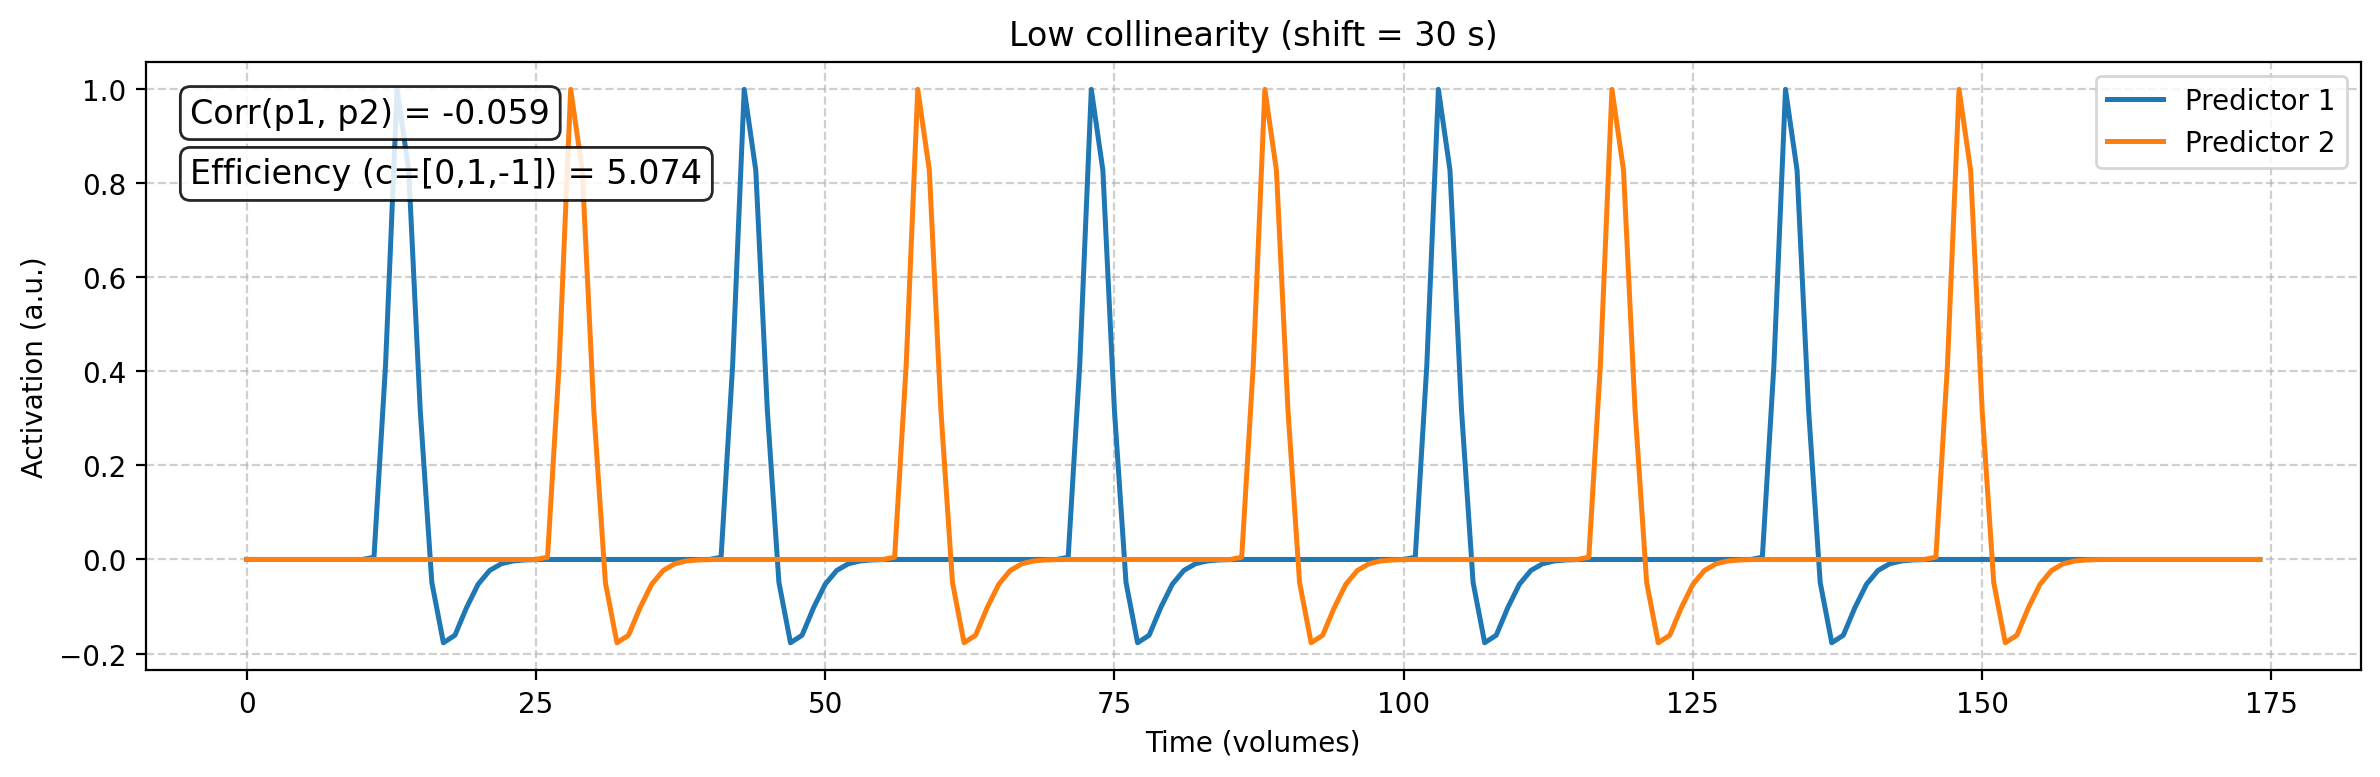

Variance predictor 1: 0.055
Variance predictor 2: 0.055


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def simulate_two_predictors(
    n_seconds=360,
    tr=2,
    onset_start=20,
    onset_stop=300,
    isi=60,
    shift=30,
    hrf=None
):
    """
    Simulate two event-related predictors with evenly spaced trials.
    Predictor 2 is shifted relative to predictor 1 by `shift` seconds.

    Parameters
    ----------
    n_seconds : int
        Total duration of the run in seconds (sampling at 1 Hz for convolution).
    tr : int or float
        Repetition time (seconds). Downsampling step after HRF convolution.
    onset_start : int
        First event onset (in seconds).
    onset_stop : int
        Last onset time (in seconds). Events occur up to but not exceeding this time.
    isi : int
        Inter-stimulus interval in seconds (spacing between events).
    shift : int
        Temporal shift (in seconds) applied to predictor 2 relative to predictor 1.
    hrf : array-like or None
        HRF sampled at 1 Hz. If None, uses glover_hrf(tr=1, oversampling=1).

    Returns
    -------
    X : ndarray, shape (n_vols, 3)
        Design matrix with columns: [intercept, pred1, pred2].
    pred1_ds, pred2_ds : ndarray
        Downsampled (TR grid) predictors (after HRF convolution).
    """
    # HRF at 1 Hz (seconds) for convolution
    if hrf is None:
        hrf = glover_hrf(tr=1, oversampling=1)
    hrf = hrf / hrf.max()

    # Stick functions sampled at 1 Hz
    pred1 = np.zeros(n_seconds, dtype=float)
    pred2 = np.zeros(n_seconds, dtype=float)

    onsets1 = np.arange(onset_start, onset_stop + 1, isi, dtype=int)
    onsets2 = onsets1 + int(shift)
    onsets2 = onsets2[onsets2 < n_seconds]  # keep on-grid onsets

    pred1[onsets1] = 1.0
    pred2[onsets2] = 1.0

    # Convolve at 1 Hz, then downsample to TR grid
    pred1_conv = np.convolve(pred1, hrf, mode="full")[:n_seconds]
    pred2_conv = np.convolve(pred2, hrf, mode="full")[:n_seconds]

    step = int(tr) if tr >= 1 else 1
    pred1_ds = pred1_conv[::step]
    pred2_ds = pred2_conv[::step]

    # Build design matrix (intercept + two predictors)
    n_vols = pred1_ds.size
    X = np.column_stack((np.ones(n_vols), pred1_ds, pred2_ds))

    return X, pred1_ds, pred2_ds

# --- Simulate with low collinearity (shifted events) ---
X, p1, p2 = simulate_two_predictors(n_seconds=350, tr=2, onset_start=20, onset_stop=300, isi=60, shift=30)
contrast = np.array([0, 1, -1])

# Correlation between predictors (multicollinearity proxy)
corr = pearsonr(X[:, 1], X[:, 2])[0]

# Design efficiency for the difference contrast c = [0, 1, -1]
design_var = contrast @ np.linalg.inv(X.T @ X) @ contrast.T
efficiency = 1.0 / design_var

# --- Plot predictors on the TR grid ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(X[:, 1], label="Predictor 1", linewidth=1.8)
ax.plot(X[:, 2], label="Predictor 2", linewidth=1.8)
ax.set_xlabel("Time (volumes)")
ax.set_ylabel("Activation (a.u.)")
ax.set_title("Low collinearity (shift = 30 s)")
ax.grid(True, linestyle="--", alpha=0.6)

# Annotations placed relative to axis limits
xlo, xhi = ax.get_xlim()
ylo, yhi = ax.get_ylim()
ax.text(xlo + 0.02*(xhi - xlo), ylo + 0.90*(yhi - ylo), f"Corr(p1, p2) = {corr:.3f}", fontsize=12,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
ax.text(xlo + 0.02*(xhi - xlo), ylo + 0.80*(yhi - ylo), f"Efficiency (c=[0,1,-1]) = {efficiency:.3f}", fontsize=12,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Report predictor variances (sample variance with ddof=1)
var_p1 = np.var(X[:, 1], ddof=1)
var_p2 = np.var(X[:, 2], ddof=1)
print(f"Variance predictor 1: {var_p1:.3f}")
print(f"Variance predictor 2: {var_p2:.3f}")

As you can see, the two predictors are **almost perfectly uncorrelated**:  
$$
\mathrm{corr}(\mathbf{X}_{1}, \mathbf{X}_{2}) \approx 0
$$
This corresponds to a design efficiency of about **4.54**.  

⚠️ Remember: the **absolute value** of efficiency is not meaningful on its own — it only becomes informative when you **compare it across different designs**.  

So let’s push things further:  
what happens if we make the predictors more correlated?  
One simple way to do this is by **shifting Predictor 2** (blue line) closer in time to Predictor 1, so that their events overlap more strongly.  
Let’s test how this induced correlation affects design efficiency.  

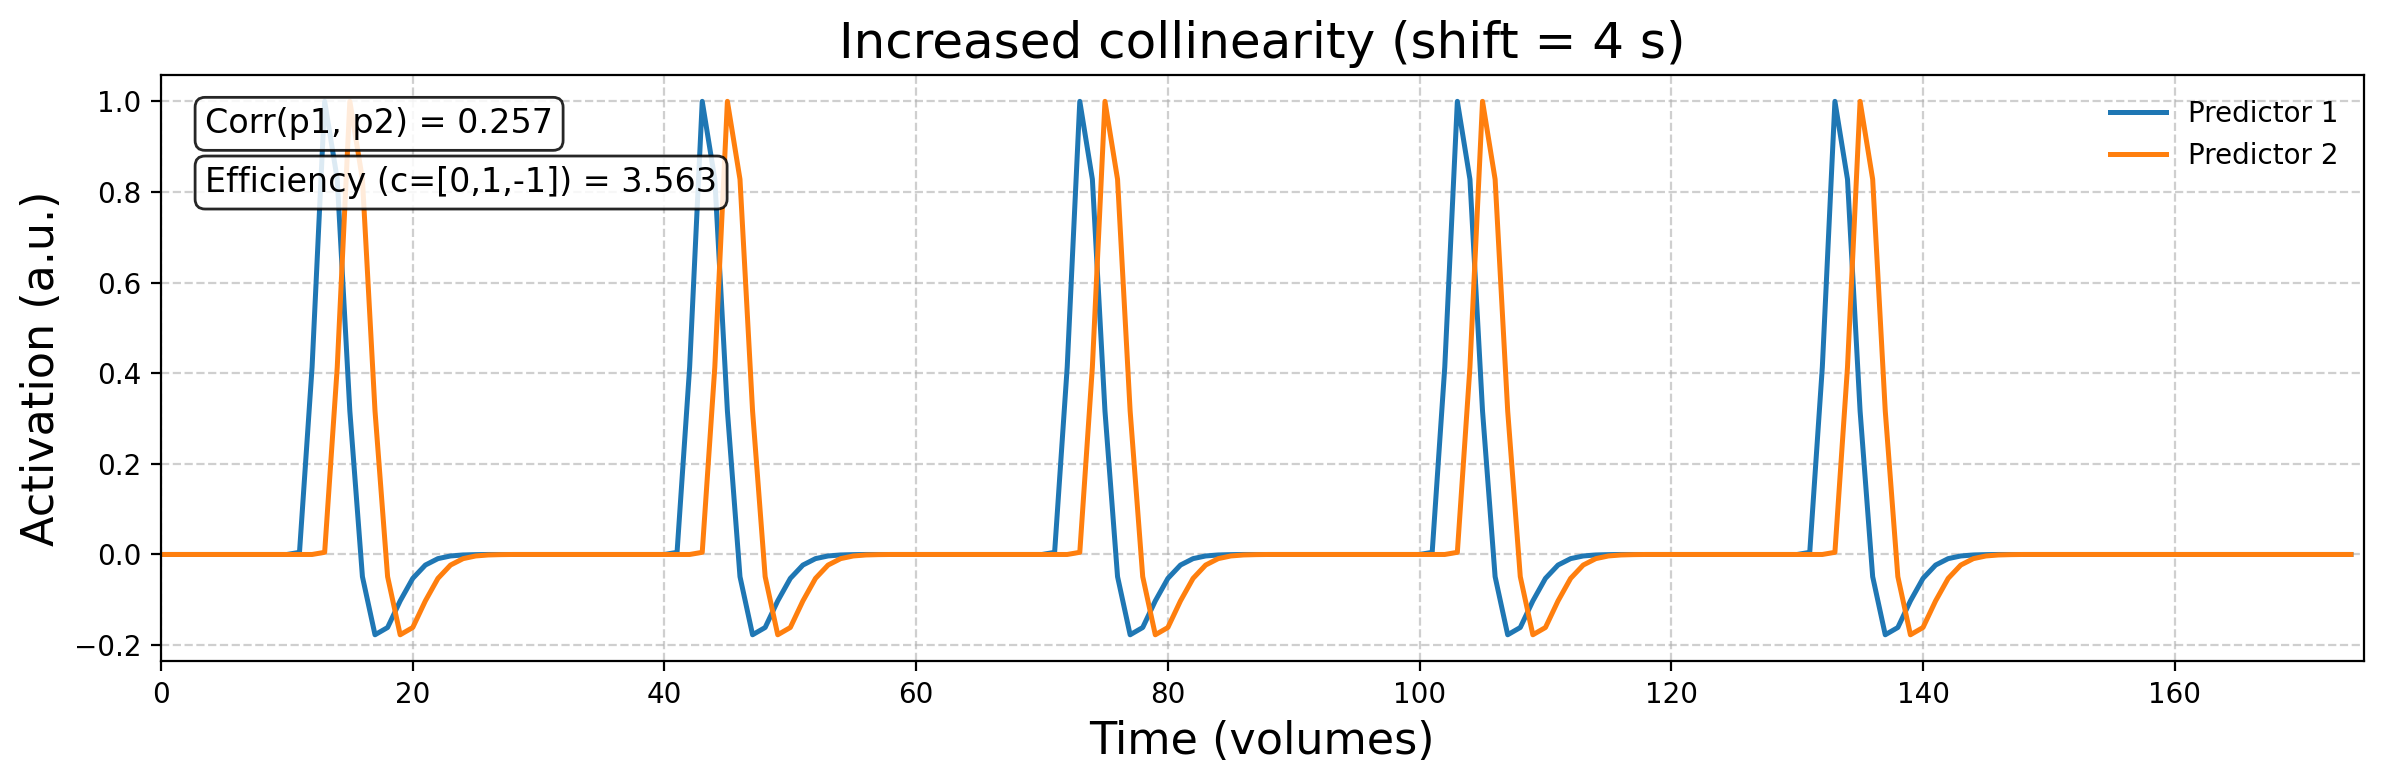

Variance predictor 1: 0.055
Variance predictor 2: 0.055


In [35]:
# Define the contrast vector (difference between Predictor 1 and Predictor 2)
cvec = np.array([0, 1, -1])

# Simulate predictors with a small shift → stronger collinearity
X2, p1_shifted, p2_shifted = simulate_two_predictors(
    n_seconds=350, tr=2, onset_start=20, onset_stop=300, isi=60, shift=4
)

# Correlation and efficiency for the difference contrast
corr2 = pearsonr(X2[:, 1], X2[:, 2])[0]
design_var2 = cvec @ np.linalg.inv(X2.T @ X2) @ cvec.T
eff2 = 1.0 / design_var2

# --- Plot predictors ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(X2[:, 1], label="Predictor 1", linewidth=1.8)
ax.plot(X2[:, 2], label="Predictor 2", linewidth=1.8)

ax.set_xlim(0, 175)
ax.set_xlabel("Time (volumes)", fontsize=16)
ax.set_ylabel("Activation (a.u.)", fontsize=16)
ax.set_title("Increased collinearity (shift = 4 s)", fontsize=18)

# Annotate correlation and efficiency dynamically
xlo, xhi = ax.get_xlim()
ylo, yhi = ax.get_ylim()
ax.text(
    xlo + 0.02*(xhi - xlo), ylo + 0.90*(yhi - ylo),
    f"Corr(p1, p2) = {corr2:.3f}",
    fontsize=12, bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)
ax.text(
    xlo + 0.02*(xhi - xlo), ylo + 0.80*(yhi - ylo),
    f"Efficiency (c=[0,1,-1]) = {eff2:.3f}",
    fontsize=12, bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

ax.legend(loc="upper right", frameon=False)
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Report predictor variances ---
var_p1 = np.var(X2[:, 1], ddof=1)
var_p2 = np.var(X2[:, 2], ddof=1)
print(f"Variance predictor 1: {var_p1:.3f}")
print(f"Variance predictor 2: {var_p2:.3f}")

In [36]:
# Calculate efficiencies for comparison
design_var1 = cvec @ np.linalg.inv(X.T @ X) @ cvec.T
eff = 1.0 / design_var1  # from the low-correlation design

design_var2 = cvec @ np.linalg.inv(X2.T @ X2) @ cvec.T
eff2 = 1.0 / design_var2  # from the high-correlation design

# Relative reduction
reduction_eff = ((eff - eff2) / eff) * 100

print(f"Efficiency (low correlation):  {eff:.3f}")
print(f"Efficiency (high correlation): {eff2:.3f}")
print(f"Relative reduction: {reduction_eff:.1f}% (at corr = {corr2:.3f})")

Efficiency (low correlation):  5.074
Efficiency (high correlation): 3.563
Relative reduction: 29.8% (at corr = 0.257)


As you can see, increasing the correlation between predictors **reduces efficiency**,  
even though the individual predictor variances remain unchanged.  

Why? Because when predictors overlap, the GLM faces **ambiguity**:  
it becomes unclear which predictor should “take the credit” for explaining the variance in $\textcolor{blue}{y}$.  
This uncertainty is exactly what drives up design variance and drives down efficiency.  

To build more intuition, let’s simulate a signal for the correlated design.  
We’ll generate $\textcolor{blue}{y}$ as a simple linear combination of the two predictors plus some random noise —  
a kind of “reverse regression” where we construct the data rather than estimate it.  

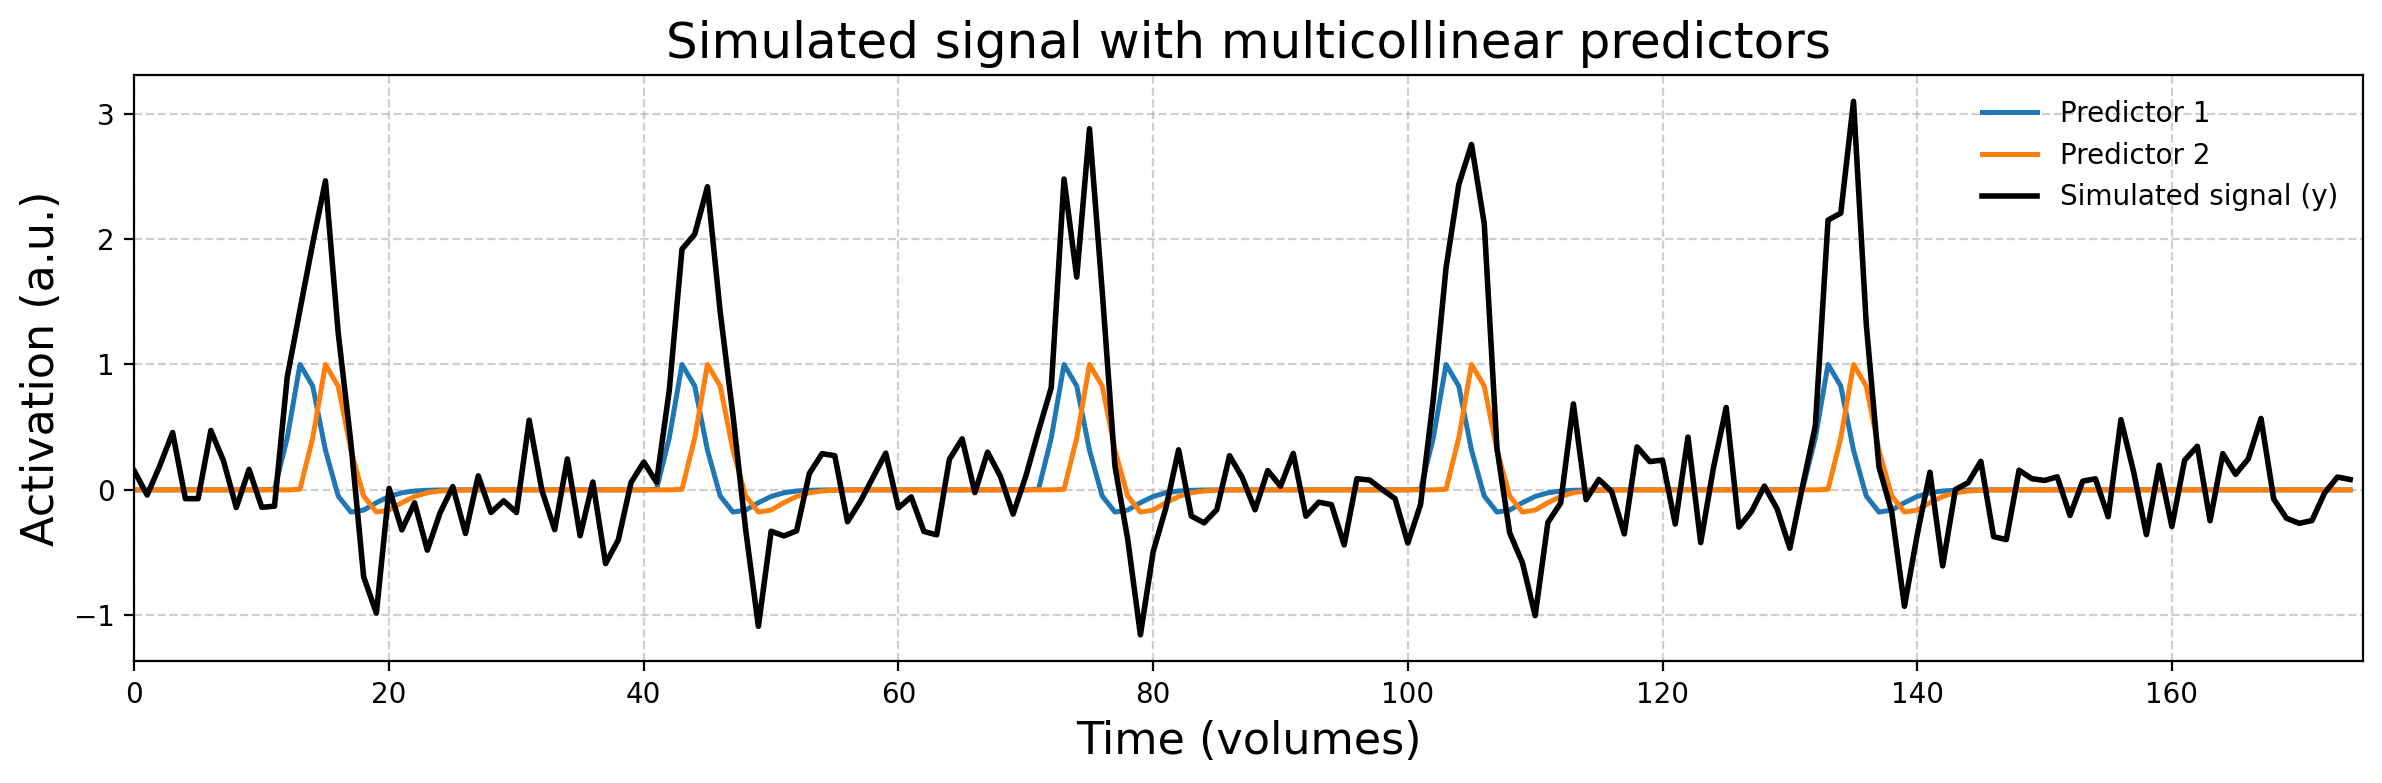

In [37]:
np.random.seed(42)

# --- Simulate signal as linear combination of predictors + Gaussian noise ---
noise = np.random.normal(0, 0.3, X2.shape[0])
sim_signal = 2 * X2[:, 1] + 2 * X2[:, 2] + noise

# --- Plot predictors and simulated signal ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(X2[:, 1], label="Predictor 1", linewidth=1.8)
ax.plot(X2[:, 2], label="Predictor 2", linewidth=1.8)
ax.plot(sim_signal, label="Simulated signal (y)", linewidth=2.0, color="black")

ax.set_xlim(0, 175)
ax.set_xlabel("Time (volumes)", fontsize=16)
ax.set_ylabel("Activation (a.u.)", fontsize=16)
ax.set_title("Simulated signal with multicollinear predictors", fontsize=18)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

Now let’s fit the GLM to this simulated signal.  
If we calculate the $\hat{\beta}$ parameters for both predictors,  
we’ll see that the model assigns them **approximately equal importance** —  
their estimated beta-values are nearly the same.  

In [38]:
# Estimate beta-parameters for the simulated signal
betas = np.linalg.inv(X2.T @ X2) @ X2.T @ sim_signal

# Print only the predictor betas (exclude intercept at index 0)
print(f"Estimated betas (predictors only): {betas[1:]}")  

Estimated betas (predictors only): [1.80161971 2.05792829]


However, the GLM cannot tell whether the peaks in the signal (black line) are driven by **Predictor 1** or **Predictor 2**.  
On average, the beta estimates are not biased — the model still finds the correct overall effect —  
but the **uncertainty** about which predictor explains the variance shows up as a **higher design variance**.  
This, in turn, leads to **lower *t*-values**, even when the betas themselves look reasonable.  

<div class='alert alert-info'>  
<b>ToThink</b> (1 point):  

Imagine that, due to a mistake in your paradigm, the two stimulus classes (Predictor 1 and Predictor 2) are always presented **at exactly the same time**.  
In other words, the blue and orange predictors are perfectly overlapping.  

In this case, the design variance cannot be computed reliably.  
Explain concisely why this happens — what property of the design matrix ($X$) breaks down when predictors are perfectly collinear?  
    
💡 Keep your explanation concise — this will be graded manually (no feedback cell).

</div>  

When the two predictors are perfectly collinear, they would form identical columns in the design matrix. Since a design matrix is rank deficient, the inverse or transpose of such a matrix is not possible, and thus would lead to an error. In this case, Var\(X1\) = Var\(X2\) = Cov\(X1, X2\); and since design variance = Var\(X1\) \+ Var\(X2\) \- 2 \* Cov\(X1, X2\) = 0, the design variance cannot be computed. 


### Evaluating multiple contrasts  

So far, we have only looked at efficiency for a **single contrast** — for example, testing whether one predictor differs from baseline, such as:  

```python
contrast_vec = np.array([0, 1, 0])
```

In practice, however, you are often interested in **several contrasts** at once.
For instance, you might want to test:
- Predictor A vs. baseline,
- Predictor B vs. baseline,
- The difference between A and B.

To handle this, we extend the definition of efficiency to the case of $K$ contrasts.
The formula becomes:

$$
\mathrm{efficiency} = \frac{K}{\sum_{k=1}^{K} \mathbf{c}{k} ( \mathbf{X}^{T}\mathbf{X} )^{-1} \mathbf{c}{k}^{T}}
$$

This approach is also known as **A-optimality**.
Conceptually, it means that the overall efficiency for multiple contrasts is **roughly the average** of the efficiencies of the individual contrasts (though not exactly a simple mean).

---

Now, let’s put this into practice: we’ll implement the calculation of overall efficiency for multiple contrasts in Python.
This will be part of a graded assignment below.

---
*Keep in mind*: evaluating multiple contrasts separately like this is not the same as performing an F-test (as we discussed in Week 2).

<div class='alert alert-warning'>  
<b>ToDo</b> (1 point):  

Using the design matrix from the correlation simulation (the variable <tt>X</tt>),  
calculate the **overall efficiency** for the following set of contrasts:  

- Predictor 1 vs. baseline  
- Predictor 2 vs. baseline  
- Predictor 1 vs. Predictor 2  

Define the contrast vectors yourself.  

Store the overall efficiency in a variable named <tt>overall_eff</tt>.  

💡 *Hint*: you’ll likely want to loop over the set of contrasts (e.g. with a list comprehension)  
and then apply the multi-contrast efficiency formula we discussed.  
</div>  

In [39]:
# --- Implement your ToDo here using X ---
# (Re-simulate the low-collinearity design to get X on the TR grid)
X, _, _ = simulate_two_predictors(
    n_seconds=350, tr=2, onset_start=20, onset_stop=300, isi=60, shift=30
)

# YOUR CODE HERE
# raise NotImplementedError()
c = np.array([
    [0, 1, 0],
    [0, 0, 1],
    [0, 1, -1]
])

sum = 0

for i in c:
    sum += (i @ inv(X.T @ X) @ i.T) # looping over contrasts
    
overall_eff = len(c) / sum
overall_eff
print(f"Overall efficiency (3 contrasts): {overall_eff:.3f}")

Overall efficiency (3 contrasts): 7.382


In [40]:
# Feedback cell
if "overall_eff" not in locals():
    print('The variable "overall_eff" is not defined. Check that you created and named the variable correctly.')
elif not np.isscalar(overall_eff):
    print('"overall_eff" should be a single value (a float).')
elif np.isnan(overall_eff) or np.isinf(overall_eff):
    print('Your overall efficiency is NaN or infinite. Check your calculation.')
elif overall_eff <= 0:
    print('Overall efficiency should be positive. Check your calculation.')
else:
    print('Your results looks reasonable.')

Your results looks reasonable.


## How can we design experiments to maximize efficiency?  

So far, we’ve focused on **why** high predictor variance and low predictor covariance are crucial  
for efficient estimation of effects (i.e., high *t*-values).  

But this naturally leads to the next question:  
**how can we actually design our experiment to achieve this?**  

As with many things in experimental design, the answer is: *it depends*.  
The optimal strategy will vary with your research question, task structure, and practical constraints. 

### Estimation vs. Detection  

The way you design your experiment — how stimuli are ordered and timed — depends on the **type of question** you want to answer.  
In univariate fMRI research, these questions are usually grouped into two broad categories:  

**1) Detection: Do different conditions elicit different levels of activity?**  
This is the most common case.  
Here, we are interested in the **amplitude** of the HRF — in other words, whether a voxel shows greater (or smaller) activation in response to a stimulus.  
You’ve already seen how to do this in Week 2, when we estimated $\hat{\beta}$ values for stimulus regressors.  
Most fMRI studies fall into this category, which is why this course focuses on **detection**.  
Designs are typically based on convolving stimulus onsets with a canonical HRF (or sometimes with a small basis set).  

**2) Estimation: How does the *shape* of the HRF differ between conditions?**  
A smaller number of studies focus not only on amplitude, but also on other HRF properties, such as its width, timing/lag, or undershoot.  
For example, some studies examine [age-related changes in HRF shape](http://www.sciencedirect.com/science/article/pii/S1053811907010877)  or [differences across clinical populations](http://www.sciencedirect.com/science/article/pii/S1053811907001371).  
These are typically analysed using **finite impulse response (FIR) models**, which allow more flexibility in capturing HRF shape.  

---

Since the vast majority of fMRI studies focus on **detection** — i.e., the amplitude of the HRF —  
we will not cover FIR models or estimation of HRF shape further in this course.  

Given that our goal is detection, the next step is to ask:  
**how should we design our experiment to maximize detection power?**  
We’ll answer this by comparing two major design families: **event-related** and **blocked** designs. 

### Event-related vs. Blocked Designs  

As you’ve seen in the readings and videos, **event-related** and **blocked** designs mainly differ in the **ordering of stimuli**:  

- **Event-related designs**: stimuli from different conditions are presented in a (pseudo-)random order.  
- **Blocked designs**: stimuli from the same condition are grouped together into blocks, shown back-to-back.  

The figure below illustrates both approaches side by side:  

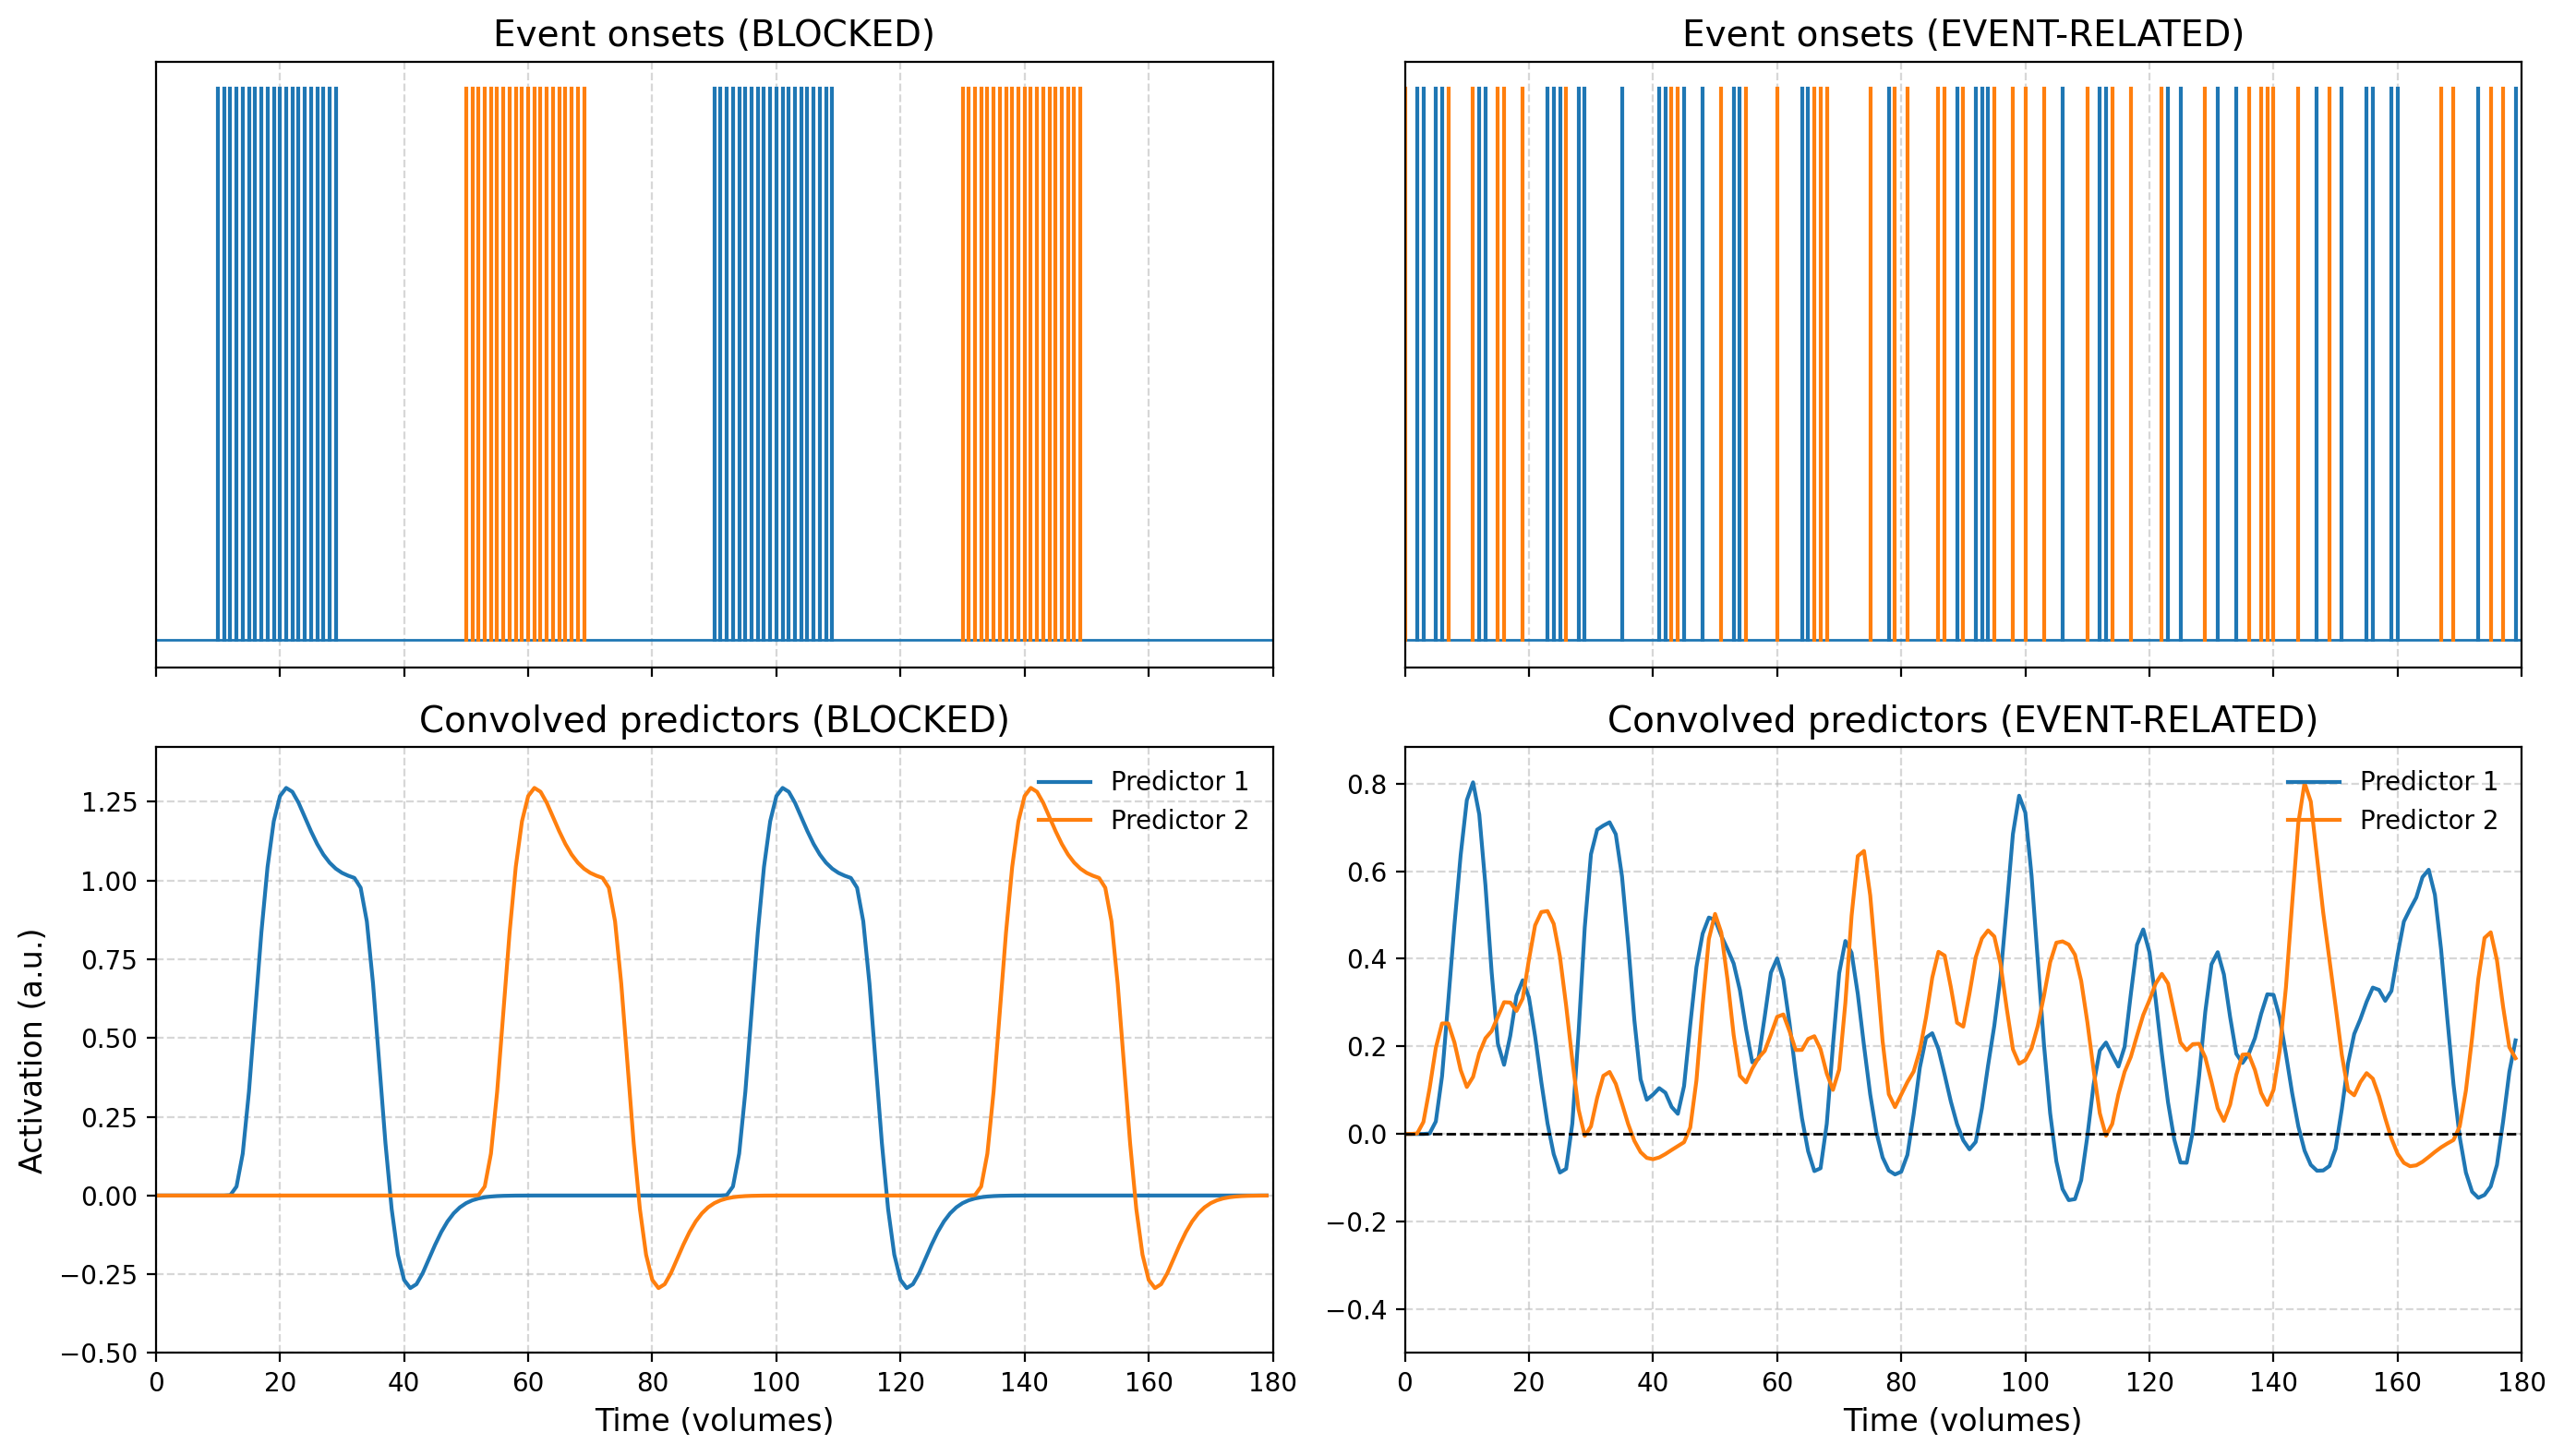

In [41]:
# --- Event-related vs Blocked design illustration ---

np.random.seed(2)

N = 180  # total time points (volumes; TR = 1 s here)
hrf = glover_hrf(tr=1, oversampling=1)

# ---------- BLOCKED DESIGN ----------
# Two blocks per condition (20 vols each), non-overlapping
blocked_pred1_onsets = list(range(10, 30)) + list(range(90, 110))
blocked_pred2_onsets = list(range(50, 70)) + list(range(130, 150))
n_stim = len(blocked_pred1_onsets)

blk_p1 = np.zeros(N, dtype=float)
blk_p2 = np.zeros(N, dtype=float)
blk_p1[blocked_pred1_onsets] = 1.0
blk_p2[blocked_pred2_onsets] = 1.0

# Convolve sticks with HRF (keep original length)
blk_p1_conv = np.convolve(blk_p1, hrf, mode="full")[:N]
blk_p2_conv = np.convolve(blk_p2, hrf, mode="full")[:N]

# Design matrix (intercept + two predictors)
icept = np.ones((N, 1))
X_blocked = np.column_stack((icept.squeeze(), blk_p1_conv, blk_p2_conv))

# ---------- EVENT-RELATED DESIGN ----------
# Random, non-overlapping onsets with the same number of events per condition
all_onsets = np.arange(N)
perm = np.random.permutation(all_onsets)
er_p1_onsets = np.sort(perm[:n_stim])
# ensure no overlap: pick next n_stim from remaining indices
remaining = np.setdiff1d(all_onsets, er_p1_onsets, assume_unique=False)
er_p2_onsets = np.sort(np.random.permutation(remaining)[:n_stim])

er_p1 = np.zeros(N, dtype=float)
er_p2 = np.zeros(N, dtype=float)
er_p1[er_p1_onsets] = 1.0
er_p2[er_p2_onsets] = 1.0

er_p1_conv = np.convolve(er_p1, hrf, mode="full")[:N]
er_p2_conv = np.convolve(er_p2, hrf, mode="full")[:N]
X_er = np.column_stack((icept.squeeze(), er_p1_conv, er_p2_conv))

# ---------- PLOTS ----------
fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

# (1) Blocked: event onsets
axs[0, 0].set_title("Event onsets (BLOCKED)", fontsize=14)
axs[0, 0].axhline(0, color="tab:blue", linewidth=1)
for o in blocked_pred1_onsets:
    axs[0, 0].plot((o, o), (0, 1), color="tab:blue")
for o in blocked_pred2_onsets:
    axs[0, 0].plot((o, o), (0, 1), color="tab:orange")
axs[0, 0].set_xlim(0, N)
axs[0, 0].set_yticks([])
axs[0, 0].grid(True, linestyle="--", alpha=0.5)

# (2) Event-related: event onsets
axs[0, 1].set_title("Event onsets (EVENT-RELATED)", fontsize=14)
axs[0, 1].axhline(0, color="tab:blue", linewidth=1)
for o in er_p1_onsets:
    axs[0, 1].plot((o, o), (0, 1), color="tab:blue")
for o in er_p2_onsets:
    axs[0, 1].plot((o, o), (0, 1), color="tab:orange")
axs[0, 1].set_xlim(0, N)
axs[0, 1].set_yticks([])
axs[0, 1].grid(True, linestyle="--", alpha=0.5)

# (3) Blocked: convolved predictors
axs[1, 0].set_title("Convolved predictors (BLOCKED)", fontsize=14)
axs[1, 0].plot(X_blocked[:, 1], color="tab:blue", label="Predictor 1")
axs[1, 0].plot(X_blocked[:, 2], color="tab:orange", label="Predictor 2")
axs[1, 0].set_xlim(0, N)
axs[1, 0].set_ylim(-0.5, max(X_blocked[:, 1].max(), X_blocked[:, 2].max()) * 1.1)
axs[1, 0].set_xlabel("Time (volumes)", fontsize=12)
axs[1, 0].set_ylabel("Activation (a.u.)", fontsize=12)
axs[1, 0].grid(True, linestyle="--", alpha=0.5)
axs[1, 0].legend(loc="upper right", frameon=False)

# (4) Event-related: convolved predictors
axs[1, 1].set_title("Convolved predictors (EVENT-RELATED)", fontsize=14)
axs[1, 1].plot(X_er[:, 1], color="tab:blue", label="Predictor 1")
axs[1, 1].plot(X_er[:, 2], color="tab:orange", label="Predictor 2")
axs[1, 1].axhline(0, ls="--", color="k", linewidth=1)
axs[1, 1].set_xlim(0, N)
axs[1, 1].set_ylim(-0.5, max(X_er[:, 1].max(), X_er[:, 2].max()) * 1.1)
axs[1, 1].set_xlabel("Time (volumes)", fontsize=12)
axs[1, 1].grid(True, linestyle="--", alpha=0.5)
axs[1, 1].legend(loc="upper right", frameon=False)

plt.tight_layout()
plt.show()

As you can see in the plots above, a **blocked design** groups trials of the same condition together into blocks, while an **event-related design** presents trials in a (pseudo-)random sequence.  
In practice, designs are often a *mixture* of the two — mostly random but with occasional mini-blocks.

So, if our goal is **detection** (i.e., estimating the amplitude of the response), which design is better?  
The answer is straightforward: **blocked designs**.

Why? Because blocked designs almost always yield **lower design variance**, thanks to:  
- **Lower covariance** (predictors are less correlated).  
- **Higher variance** (predictors have more spread).  

Let’s check this explicitly for the two designs above.  
We’ll start by looking at **predictor correlation** (a standardized form of covariance, and therefore easier to interpret).  

In [42]:
from scipy.stats import pearsonr

# Compute predictor correlations for blocked vs event-related designs
corr_blocked, _ = pearsonr(X_blocked[:, 1], X_blocked[:, 2])
corr_er, _ = pearsonr(X_er[:, 1], X_er[:, 2])

print(f"Predictor correlation (blocked design): {corr_blocked:.3f}")
print(f"Predictor correlation (event-related design): {corr_er:.3f}")

Predictor correlation (blocked design): -0.234
Predictor correlation (event-related design): -0.284


<div class='alert alert-warning'>
<b>ToDo</b> (1 point):

We found that predictor <em>correlation</em> is lower in blocked designs than in event-related designs.  
Now compare their <em>variance</em>.

Compute the (sample) variance for **Predictor 1** and **Predictor 2** in both designs:
- Blocked design: <tt>X_blocked</tt>
- Event-related design: <tt>X_er</tt>

Use the predictors in columns <code>X[:, 1]</code> and <code>X[:, 2]</code>  
(Intercept is column <code>0</code>).

Recall the **sample variance** formula (ddof = 1):
\[
\mathrm{var}[x] = \frac{1}{N-1}\sum_{i=1}^{N}\left(x_i - \bar{x}\right)^2
\]

Store your results in:
- <tt>blocked_pred1_var</tt>
- <tt>blocked_pred2_var</tt>
- <tt>er_pred1_var</tt>
- <tt>er_pred2_var</tt>

⚠️ Do <strong>not</strong> use <tt>np.var</tt>. Implement the formula explicitly (vectorised):  
mean → squared deviations → sum → divide by <tt>(N - 1)</tt>.

<em>Sanity check:</em> All variances must be ≥ 0. Blocked predictors will often (not always) show larger variance than event-related predictors due to sustained block activity.
</div>

In [43]:
# --- Implement your ToDo here ---

# YOUR CODE HERE
# blocked designs
blocked_pred1_var = (np.sum((X_blocked[:, 1] - np.mean(X_blocked[:, 1])) ** 2)) / (len(X_blocked) - 1)
blocked_pred2_var = (np.sum((X_blocked[:, 2] - np.mean(X_blocked[:, 2])) ** 2)) / (len(X_blocked) - 1)

# event-related designs
er_pred1_var = (np.sum((X_er[:, 1] - np.mean(X_er[:, 1])) ** 2)) / (len(X_er) - 1)
er_pred2_var = (np.sum((X_er[:, 2] - np.mean(X_er[:, 2])) ** 2)) / (len(X_er) - 1)

print(blocked_pred1_var, blocked_pred2_var, er_pred1_var, er_pred2_var)
# raise NotImplementedError()

0.21202110388243742 0.21202099143501266 0.053520186718455695 0.03220994128469804


In [44]:
# Feedback cell
errors = 0

# Check if variables are defined
for variable in ['blocked_pred1_var', 'blocked_pred2_var', 'er_pred1_var', 'er_pred2_var']:
    if variable not in locals():
        print(f'The variable "{variable}" is not defined. Check that you created and named the variable correctly.')
        errors += 1

# Check if the variable types match
if errors == 0:
    for name, variable in zip(['blocked_pred1_var', 'blocked_pred2_var', 'er_pred1_var', 'er_pred2_var'], 
                              [blocked_pred1_var, blocked_pred2_var, er_pred1_var, er_pred2_var]):
        if not np.isscalar(variable):
            print(f'"{name}" should be a single numeric value (a float).')
            errors += 1
        elif np.isnan(variable) or np.isinf(variable):
            print(f'"{name}" is NaN or infinite. Check your calculation.')
            errors += 1
        elif variable <= 0:
            print(f'"{name}" should be positive (design variance must be positive).')
            errors += 1

if errors == 0:
    print('Yours results look reasonable.')
else:
    print(f'The automated checks found {errors} potential issue(s) in your code.')

Yours results look reasonable.


<div class='alert alert-info'>
<b>ToThink</b> (1 point):

High predictor variance is crucial for efficient designs.  
In blocked designs, this is strongly influenced by one key property of the BOLD response.  

👉 Which property (or assumption) of the BOLD signal is most important here?  
Write your answer in the text cell below.
    
💡 Keep your explanation concise — this will be graded manually (no feedback cell).
</div>

The relevant property is the linearity of the BOLD response. Since the BOLD response is linear, presenting multiple stimuli in close succession leads to a signal larger than the signal observed after presenting just one stimulus. Since the larger signal leads to a larger deviation from the mean, the predictor variance also increases.


<div class='alert alert-warning'>
<b>ToDo / ToThink</b> (2 points)

In the previous exercise, you saw that blocked designs typically yield higher predictor variance and are therefore more efficient.  
At first glance, this seems to fit the general idea in psychology that *more trials = more power*.  

In fMRI, however, this logic breaks down: after a certain point, making blocks longer actually makes the design <em>less</em> efficient.  

Below, we provide a function that simulates a blocked design predictor for an experiment of fixed duration (500 seconds, TR = 1).  
For example, calling the function with <tt>trials=10</tt> creates a block of 10 consecutive 1-second events.  

Suppose we want to test that predictor against baseline.  

👉 In the text cell below, explain why adding more and more trials does <em>not</em> necessarily lead to higher efficiency, when total experiment time is fixed.  
**Hint**: try setting <tt>N_TRIALS = 500</tt> and inspect the resulting predictor. What happens?
    
💡 Keep your explanation concise — this will be graded manually (no feedback cell).
</div>

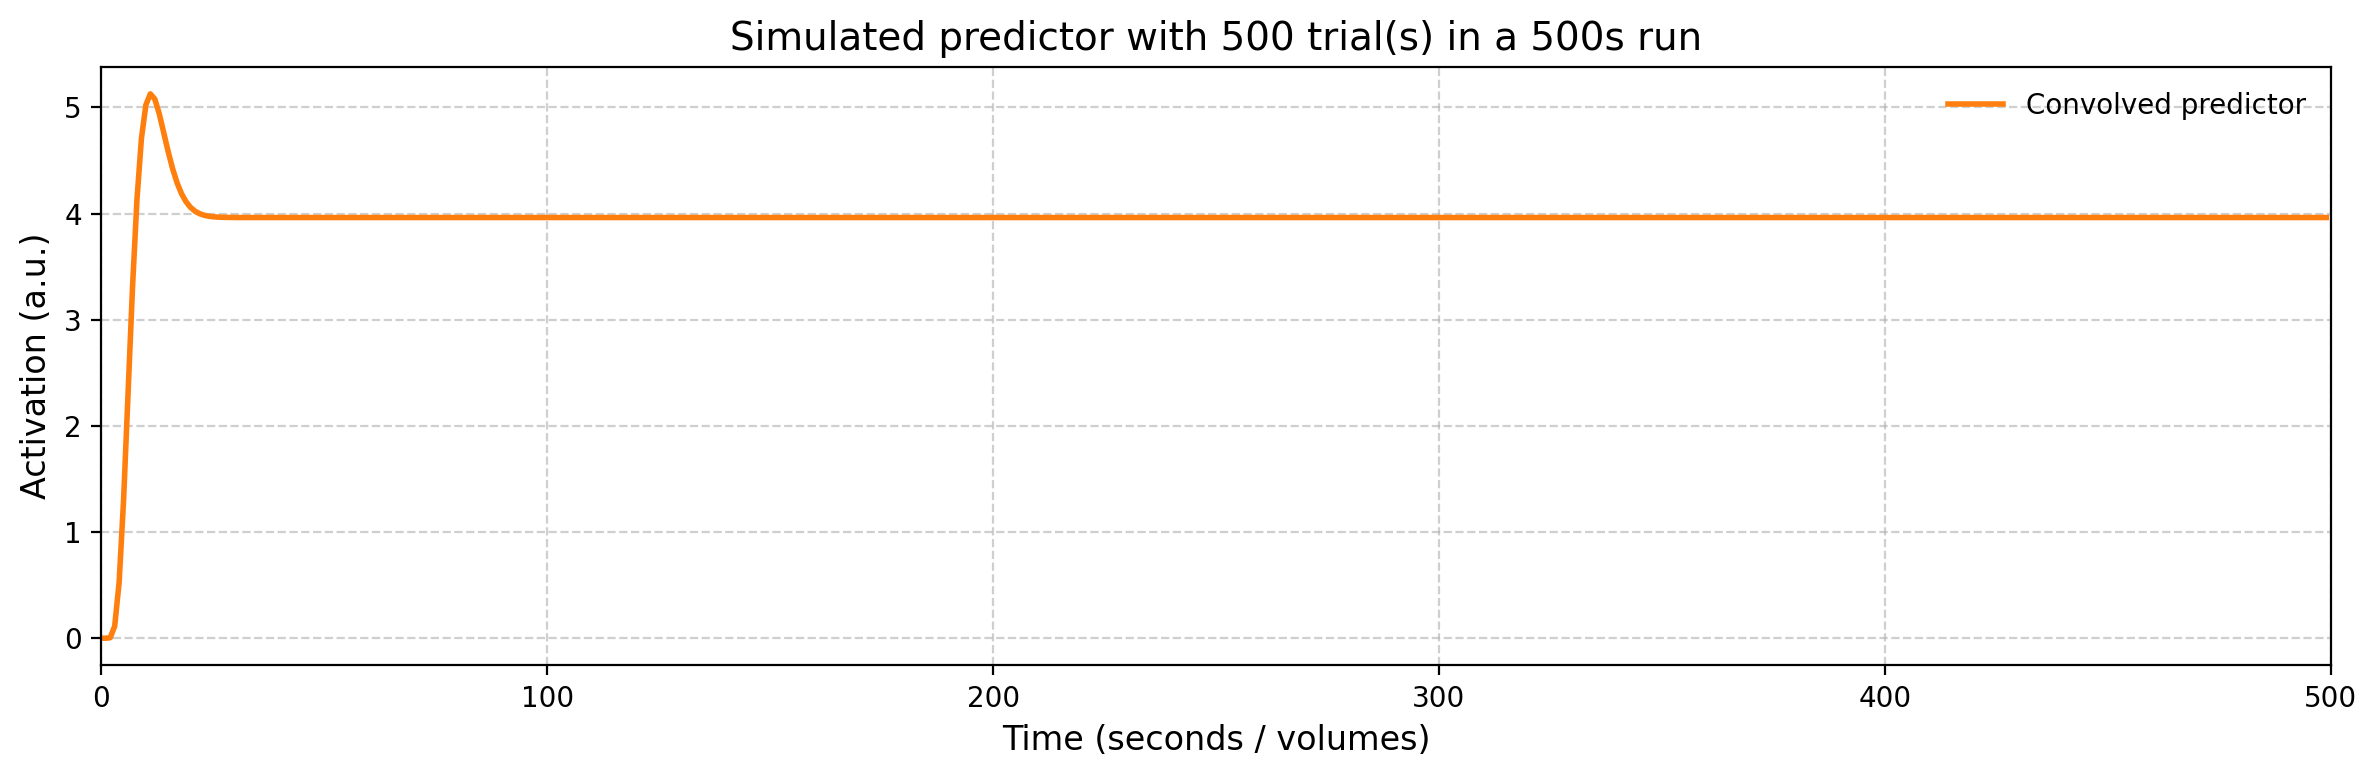

In [45]:
def simulate_single_predictor(trials, time_exp=500):
    """
    Simulate a single blocked-design predictor for a fixed-length experiment.

    Parameters
    ----------
    trials : int
        Number of consecutive 1 s events at the start of the run (i.e., block length).
    time_exp : int, default=500
        Total experiment duration in seconds (TR = 1 s).

    Returns
    -------
    X : (time_exp, 2) ndarray
        Design matrix with columns: [intercept, convolved predictor].
    pred_conv : (time_exp,) ndarray
        Convolved predictor timecourse (HRF units).
    """
    if trials < 0:
        raise ValueError("`trials` must be non-negative.")
    if trials > time_exp:
        raise ValueError("Cannot have more trials than time points (`trials <= time_exp`).")

    # Stick function: a single block of `trials` consecutive events (1 s each)
    pred = np.zeros(time_exp, dtype=float)
    pred[:trials] = 1.0

    # Convolve with canonical HRF sampled at 1 Hz (TR = 1)
    hrf = glover_hrf(tr=1, oversampling=1)
    hrf = hrf / hrf.max()  # normalize for easier visual comparison across settings
    pred_conv = np.convolve(pred, hrf, mode="full")[:time_exp]

    # Build design matrix (intercept + convolved predictor)
    X = np.column_stack((np.ones(time_exp), pred_conv))
    return X, pred_conv


# --- Explore the effect of changing the number of trials in a fixed-length run ---
contrast = np.array([0, 1])  # predictor vs baseline

# Change this value to investigate how block length affects the predictor/efficiency
N_TRIALS = 500
X, pred_conv = simulate_single_predictor(trials=N_TRIALS, time_exp=500)

# --- Plot the convolved predictor ---
plt.figure(figsize=(12, 4))
plt.plot(pred_conv, label="Convolved predictor", linewidth=2, color="tab:orange")
plt.title(f"Simulated predictor with {N_TRIALS} trial(s) in a 500s run", fontsize=14)
plt.xlabel("Time (seconds / volumes)", fontsize=12)
plt.ylabel("Activation (a.u.)", fontsize=12)
plt.xlim(0, pred_conv.size)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

The BOLD response does not continue to increase as more stimuli of the same type are presented in close succession due to a saturation effect \(i.e., an eventual breakdown of the assumption of linearity\). Instead, the voxel being measured simply shows a consistently high activation across the remaining trials. Since the variance of the predictor is the average \(squared\) deviation from the mean, this high but stable signal that does not substantially increase leads to a smaller predictor variance. In order to get a high variance, the signal must return to baseline after it has reached a peak.


### The "paradox" of efficiency  

So far, we’ve seen that blocked designs are **mathematically more efficient** than event-related designs.  
Does that mean we should always use blocked designs?  

👉 The answer is no.  

While efficiency is important, we must not forget that **fMRI measures signals from living, breathing human beings**. And humans get bored, drowsy, or inattentive when a task is monotonous and predictable.  

Blocked designs often suffer from exactly these issues:  
- **Predictability and monotony** → participants disengage.  
- **Habituation** → repeated exposure can dampen the BOLD response.  
- **Non-linearities** → violations of the assumption that the BOLD response is *linear and time-invariant (LTI)*.  

This creates a paradox:  
> The mathematically most efficient designs (blocked) are also the ones most likely to undermine the very signal we want to measure.  

In practice, researchers often prefer **(semi-)randomized event-related designs**.  
They sacrifice some statistical efficiency, but they reduce the risk of boredom, predictability, and habituation — all of which can lower the *actual* measured signal.  

Up next, we’ll look at how to make the most of event-related (random) designs by optimizing their structure.

### Improving design efficiency for event-related designs: jittering  

In most fMRI experiments, stimuli are separated by short pauses without stimulation.  
This pause is called the **inter-stimulus interval (ISI)** (sometimes also referred to as the *stimulus onset asynchrony, SOA*).  

The ISI is simply the time between the onset of one stimulus and the onset of the next.  
For example, in the design shown below, each stimulus is followed by an 8-second gap — an ISI of 8 s:  

![img](https://docs.google.com/drawings/d/e/2PACX-1vQwC4chpnzsDEzKhrKH_WHhMX7vJswY4H0pkyIxdlxI_I2GG5e8i6lsiWUO0SUk7NBgdV-vXD5PIleJ/pub?w=950&h=397)

Let’s simulate a simple event-related experiment with two predictors: **circles** and **squares**.  
Each stimulus lasts 1 second and is followed by an **8-second ISI** (as in the figure above).  

Suppose we want to test both conditions against baseline (i.e., *circles > baseline* and *squares > baseline*).  

We’ll now:  
1. Generate one design matrix with this fixed ISI,  
2. Compute the efficiency for these contrasts, and  
3. Visualize the resulting predictors.

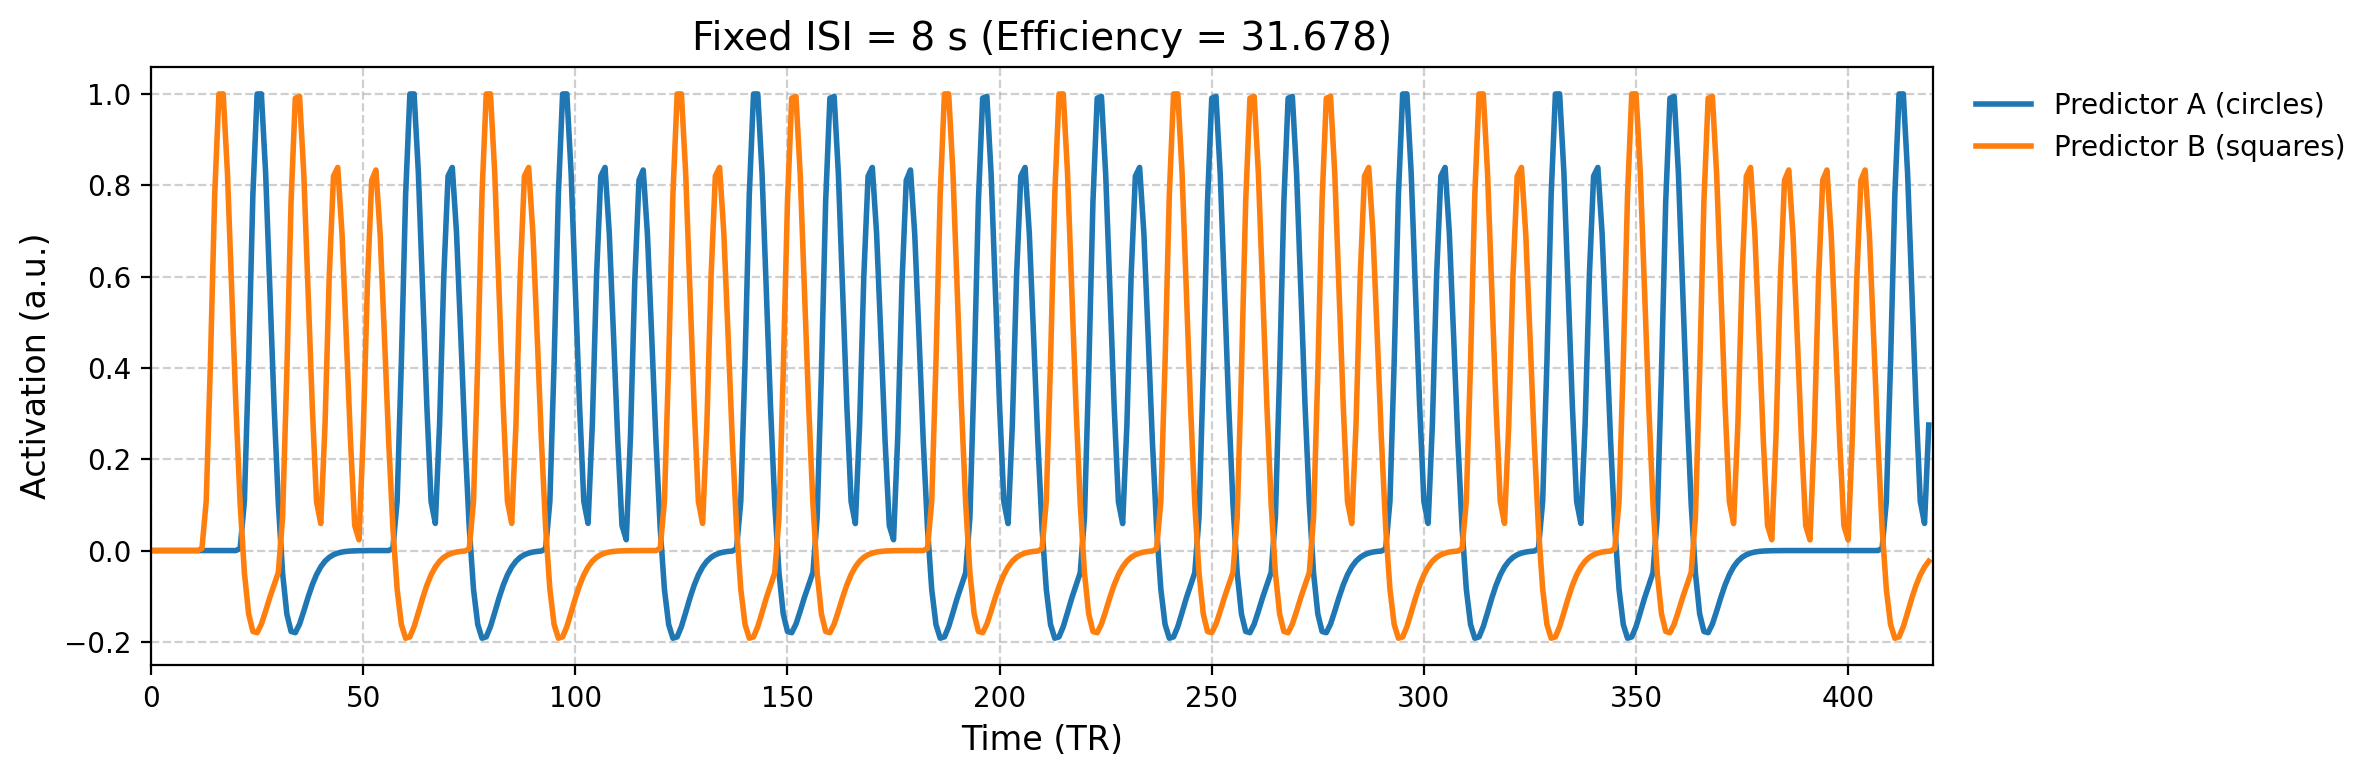

In [46]:
def simulate_data_fixed_ISI(N=420, isi=8, stim_dur=1, start=10, seed=0):
    """
    Simulate an event-related design with a fixed ISI for two conditions (A, B).
    Each event lasts `stim_dur` seconds, followed by `isi` seconds (so period = stim_dur + isi).

    Parameters
    ----------
    N : int
        Total number of time points (TR = 1 s assumed).
    isi : int
        Inter-stimulus interval in seconds.
    stim_dur : int
        Duration of each stimulus in seconds.
    start : int
        First possible onset time (in seconds).
    seed : int
        Random seed for reproducible shuffling of condition labels.

    Returns
    -------
    X : (N, 3) ndarray
        Design matrix with columns: [intercept, reg_A, reg_B].
    eff : float
        A-optimality efficiency for the two contrasts against baseline ([0,1,0] and [0,0,1]).
    stims_A, stims_B : (N,) ndarrays
        Binary stick functions for conditions A and B (pre-convolution).
    """
    rng = np.random.default_rng(seed)
    hrf = glover_hrf(tr=1, oversampling=1)
    hrf = hrf / hrf.max()

    period = stim_dur + isi  # here: 1 + 8 = 9 s
    # Generate regular onsets, keep them in-bounds
    onsets = np.arange(start, N - stim_dur, period, dtype=int)

    # Ensure an even number of trials so A/B have equal counts
    if onsets.size % 2 == 1:
        onsets = onsets[:-1]

    n_trials = onsets.size
    labels = np.array([1] * (n_trials // 2) + [2] * (n_trials // 2))
    rng.shuffle(labels)

    # Build stick functions
    stims_A = np.zeros(N, dtype=int)
    stims_B = np.zeros(N, dtype=int)
    for onset, lab in zip(onsets, labels):
        if lab == 1:
            stims_A[onset:onset + stim_dur] = 1
        else:
            stims_B[onset:onset + stim_dur] = 1

    # Convolve with HRF (keep original length)
    reg_A = np.convolve(stims_A, hrf, mode="full")[:N]
    reg_B = np.convolve(stims_B, hrf, mode="full")[:N]

    # Design matrix
    X = np.column_stack((np.ones(N), reg_A, reg_B))

    # Efficiency (A-optimality) for two contrasts against baseline
    c = np.array([[0, 1, 0],
                  [0, 0, 1]])
    XtX_inv = np.linalg.inv(X.T @ X)
    dvars = [(ck @ XtX_inv @ ck.T) for ck in c]
    eff = c.shape[0] / np.sum(dvars)

    return X, eff, stims_A, stims_B


# --- Simulate and plot a fixed-ISI design (1 s stim, 8 s ISI) ---
X, eff, stims_A, stims_B = simulate_data_fixed_ISI(N=420, isi=8, stim_dur=1, start=10, seed=2)

plt.figure(figsize=(12, 4))
plt.plot(X[:, 1], label="Predictor A (circles)", linewidth=2, color="tab:blue")
plt.plot(X[:, 2], label="Predictor B (squares)", linewidth=2, color="tab:orange")
plt.title(f"Fixed ISI = 8 s (Efficiency = {eff:.3f})", fontsize=14)
plt.xlabel("Time (TR)", fontsize=12)
plt.ylabel("Activation (a.u.)", fontsize=12)
plt.xlim(0, X.shape[0])
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

In practice, researchers rarely stick to a *fixed* ISI.  
Instead, they often vary the ISI from trial to trial — a strategy called **jittering**.  

Typically, the ISIs are sampled from a probability distribution (e.g., a truncated exponential or normal distribution).  
Compared to fixed ISIs, jittering can improve efficiency because it:  
- reduces covariance between predictors, and  
- increases predictor variance.  

Let’s simulate another design, this time with ISIs that vary randomly between **2 and 6 seconds** (average ≈ 4 seconds, but variable across trials):

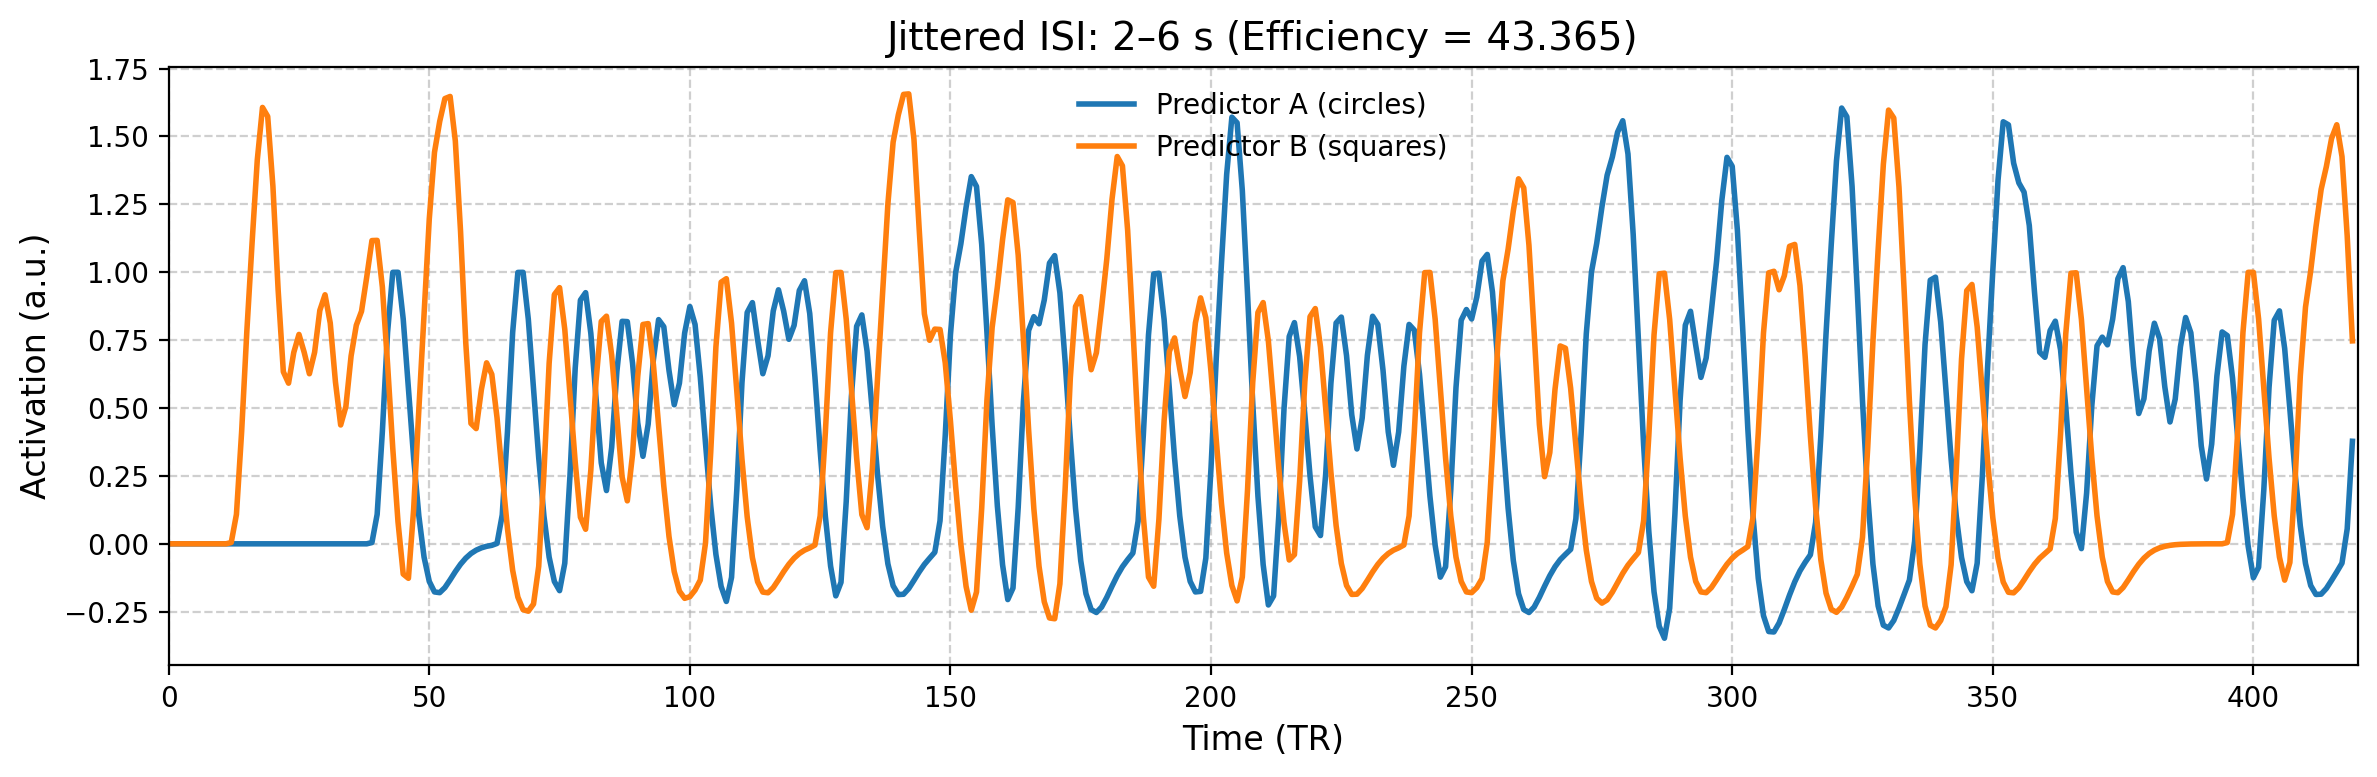

In [47]:
def simulate_data_jittered_ISI(N=420, isi_min=2, isi_max=6, stim_dur=1, start=10):
    """
    Simulate an event-related design with *jittered* ISIs for two conditions (A, B).

    Parameters
    ----------
    N : int
        Total number of time points (assume TR = 1 s).
    isi_min, isi_max : int
        Minimum and maximum ISI (in seconds). Actual ISIs are sampled uniformly in [isi_min, isi_max].
    stim_dur : int
        Duration of each stimulus in seconds.
    start : int
        First possible onset time (in seconds).
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    X : (N, 3) ndarray
        Design matrix with columns: [intercept, reg_A, reg_B].
    eff : float
        A-optimality efficiency for the two contrasts against baseline ([0,1,0] and [0,0,1]).
    onsets : list[int]
        List of event onset times (in seconds).
    labels : (n_trials,) ndarray of int
        1 for condition A, 2 for condition B.
    """

    # Build jittered onsets (1 s stim + jittered ISI in [isi_min, isi_max])
    onsets = []
    t = start
    while t + stim_dur < N:
        onsets.append(int(t))
        isi = rng.integers(isi_min, isi_max + 1)  # inclusive of isi_max
        t = t + stim_dur + isi

    # Ensure even number of trials so A/B get equal counts
    if len(onsets) % 2 == 1:
        onsets = onsets[:-1]

    n_trials = len(onsets)
    labels = np.array([1] * (n_trials // 2) + [2] * (n_trials // 2))
    rng.shuffle(labels)

    # Stick functions
    stims_A = np.zeros(N, dtype=int)
    stims_B = np.zeros(N, dtype=int)
    for onset, lab in zip(onsets, labels):
        if lab == 1:
            stims_A[onset:onset + stim_dur] = 1
        else:
            stims_B[onset:onset + stim_dur] = 1

    # Convolve with canonical HRF (1 Hz) and trim
    hrf = glover_hrf(tr=1, oversampling=1)
    hrf = hrf / hrf.max()
    reg_A = np.convolve(stims_A, hrf, mode="full")[:N]
    reg_B = np.convolve(stims_B, hrf, mode="full")[:N]

    # Design matrix
    X = np.column_stack((np.ones(N), reg_A, reg_B))

    # Efficiency (A-optimality) for A>baseline and B>baseline
    c = np.array([[0, 1, 0],
                  [0, 0, 1]])
    XtX_inv = np.linalg.inv(X.T @ X)
    dvars = [ck @ XtX_inv @ ck.T for ck in c]
    eff = c.shape[0] / np.sum(dvars)

    return X, eff, onsets, labels


# --- Simulate and plot a jittered-ISI design (ISI ∈ [2, 6], mean ≈ 4 s) ---
N = 420
rng = np.random.default_rng(23)
X_jit, eff_jit, onsets_jit, labels_jit = simulate_data_jittered_ISI(
    N=N, isi_min=2, isi_max=6, stim_dur=1, start=10,
)

plt.figure(figsize=(12, 4))
plt.plot(X_jit[:, 1], label="Predictor A (circles)", linewidth=2, color="tab:blue")
plt.plot(X_jit[:, 2], label="Predictor B (squares)", linewidth=2, color="tab:orange")
plt.title(f"Jittered ISI: 2–6 s (Efficiency = {eff_jit:.3f})", fontsize=14)
plt.xlabel("Time (TR)", fontsize=12)
plt.ylabel("Activation (a.u.)", fontsize=12)
plt.xlim(0, N)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

As you can see in the plot above, jittering improved design efficiency quite a bit! It is important to realize that jittering does not *always* improve design efficiency, but by "injecting" randomness (by selecting semi-random ISIs) it allows for *a larger variety* of designs, which also include designs that happen to be more efficient than the fixed-ISI designs. 

You'll follow up on this idea in the next ToDo.

<div class='alert alert-warning'>
<b>ToDo</b> (3 points)  

In the previous examples, you saw that jittered-ISI designs can be more efficient than fixed-ISI designs. More importantly, jittering increases the *range* of possible designs, which means you can end up with both more efficient *and* less efficient designs compared to the fixed-ISI case. A good way to visualize this is to run both simulations many times and compare the distributions of efficiencies.  

Your task:  
- Run the functions <tt>simulate_data_fixed_ISI</tt> and <tt>simulate_data_jittered_ISI</tt> each **1000 times** (use the default <tt>N=420</tt>).  
- Collect the efficiency values from each run (you only need the *second* output of the functions).  
- Plot both distributions as histograms **in a single plot**.  

Make sure to:  
- Call <tt>plt.hist</tt> twice (once for each set of efficiencies) before <tt>plt.show()</tt>.  
- Add a legend that labels which histogram belongs to which design.  
- Label your x-axis and y-axis appropriately (look up what histogram axes represent if you’re unsure).  
- Give your plot a clear, descriptive title.  

💡 This will be graded manually (no feedback cell).
</div>

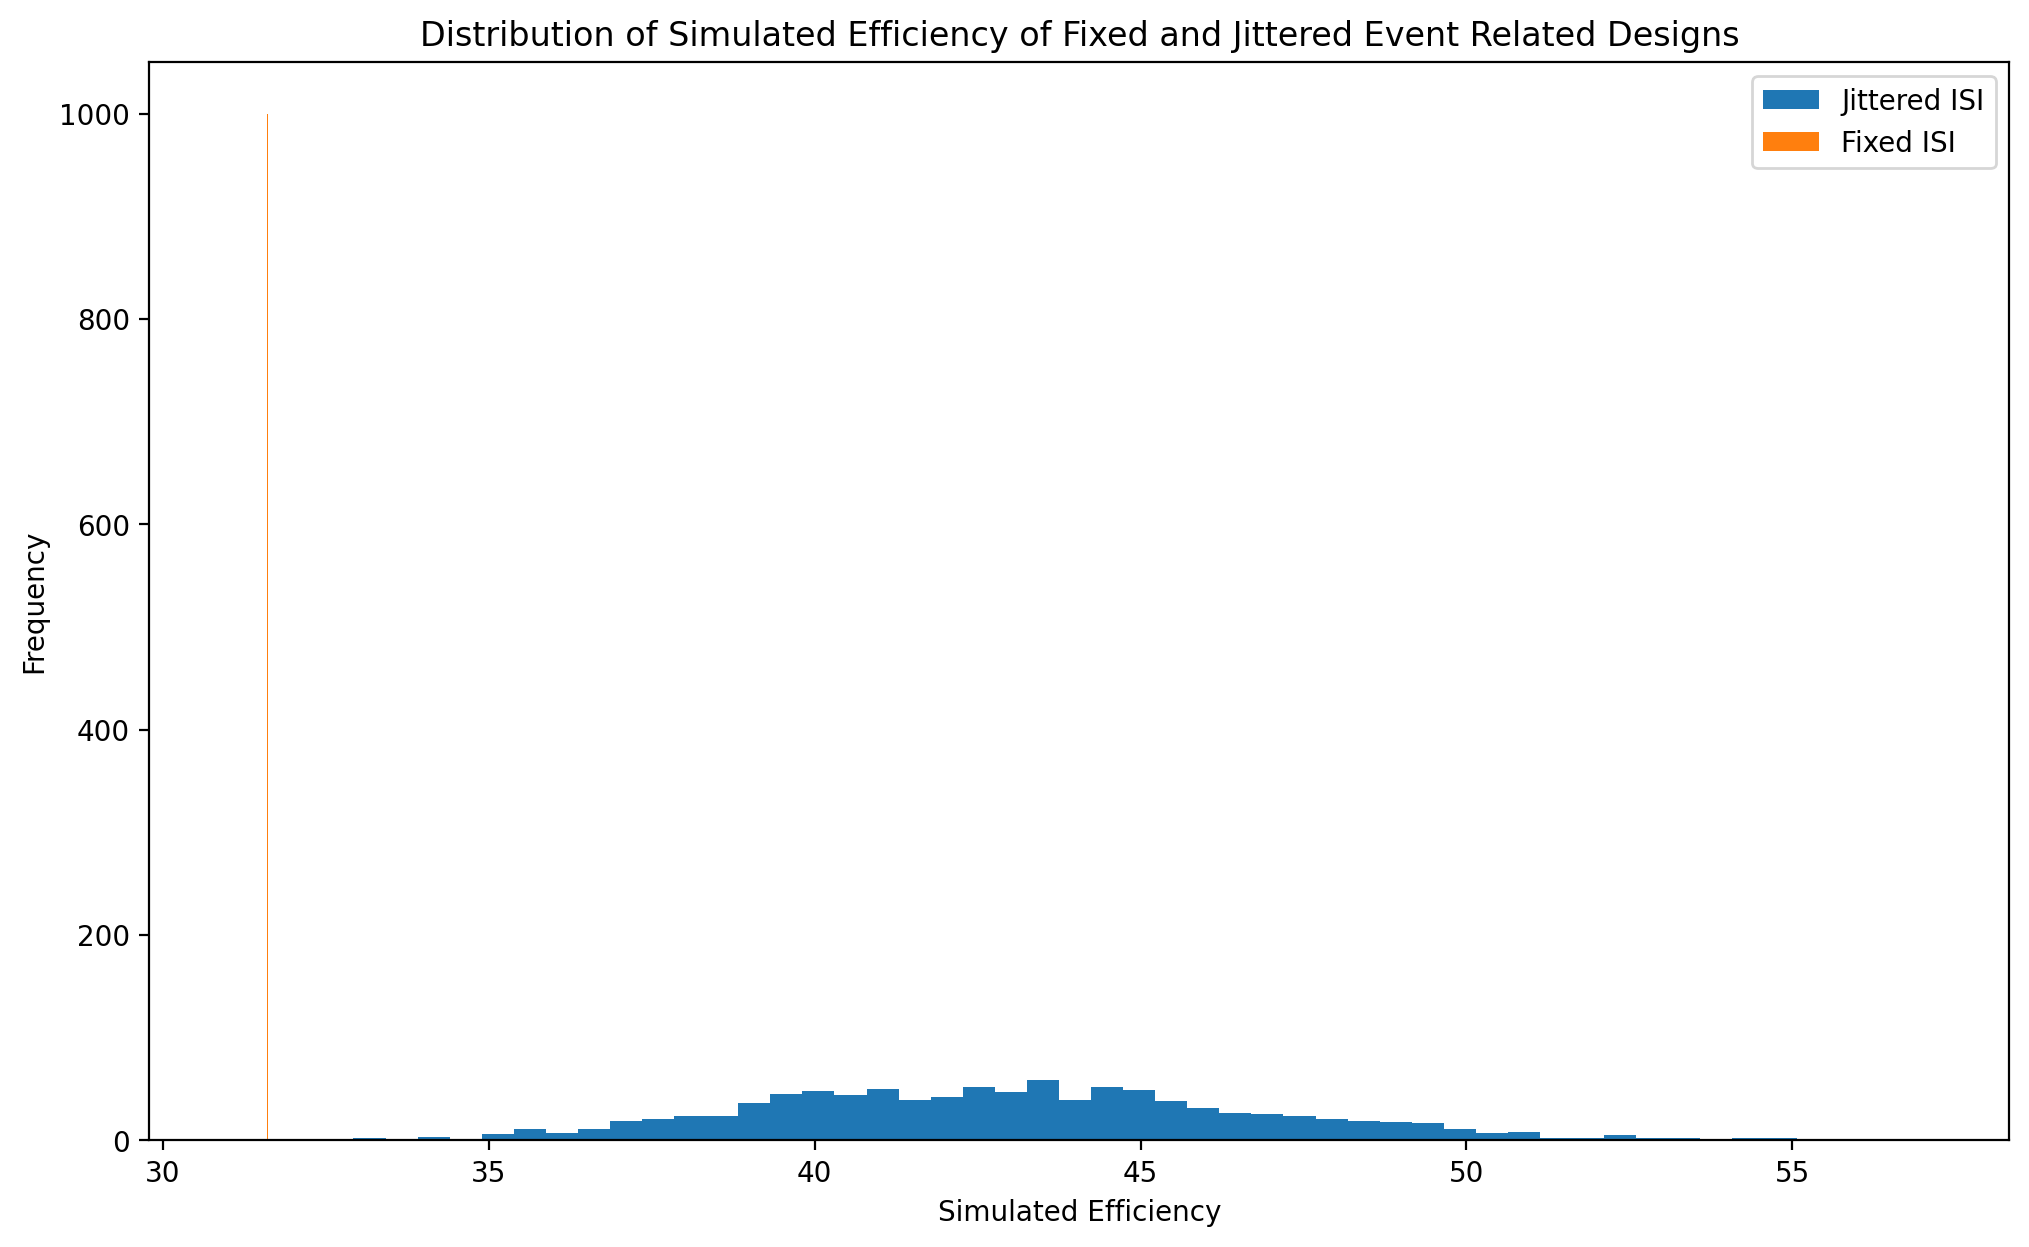

In [48]:
iterations = 1000
rng = np.random.default_rng(23)

# --- Implement your ToDo here ---
# YOUR CODE HERE
sim_jit = []
sim_fix = []

while len(sim_jit) < iterations :
    sim_jit.append(simulate_data_jittered_ISI()[1])
    sim_fix.append(simulate_data_fixed_ISI()[1])

plt.hist(sim_jit, bins = 50)
plt.hist(sim_fix, bins = 50)
plt.xlabel('Simulated Efficiency')
plt.ylabel('Frequency')
plt.title('Distribution of Simulated Efficiency of Fixed and Jittered Event Related Designs')
plt.legend(['Jittered ISI', 'Fixed ISI'])
plt.show()
# raise NotImplementedError()

In [49]:
# Please run this cell to clear up space on the server. If you need the data again, just run the download cell at the beginning of the notebook.

for file in ['data_contrast_example.npz', 'iq_variance_example.npz', 'y_reward_signal.npy', 'weight_height_data.npz']:
    if os.path.isfile(file):
        os.remove(file)
        print(f'Removed file {file}')
    else:
        print(f'File {file} not found')

Removed file data_contrast_example.npz
Removed file iq_variance_example.npz
Removed file y_reward_signal.npy
Removed file weight_height_data.npz


### 🎉 Well done! 

In this section, we explored how to structure fMRI experiments to achieve **high design efficiency**, thereby maximizing the chance of detecting significant effects. The optimal strategy depends on your research goal:  

- **Estimation** (studying the full *shape* of the HRF)  
- **Detection** (testing whether the *amplitude* of the response differs between conditions)  

Most fMRI studies aim for **detection**, where designs fall broadly into two categories:  

- **Blocked designs**: Statistically more efficient, as they typically have higher predictor variance and lower covariance.  
- **Event-related designs**: Less efficient on paper, but preferable in practice since they reduce problems such as boredom, predictability, and violations of the linear time-invariance assumption of the BOLD response.  

When using **event-related designs**, efficiency can often be improved through **jittering** the inter-stimulus intervals (ISIs), which increases variability and reduces predictor covariance.  

<div class='alert alert-success'>
    <b>Tip</b>: When you are finished with your work, click "Validate" at the top of the notebook. This will run the entire notebook and tell you with there are any errors.
</div>